In [42]:
import numpy as np
import matplotlib.pyplot as plt
import glob
from scipy.linalg import sqrtm
from pathlib import Path
%matplotlib widget

def load_npy(root_folder):
    """Load every .npy under root_folder into a dict keyed by filename stem.

    Name-based access replaces the old positional list: alphabetical file order
    shifts whenever a run saves a different set of arrays (folder 1 vs 2-5),
    which silently mis-indexes plots.
    """
    root = Path(root_folder)
    return {file.stem: np.load(file) for file in root.rglob("*.npy")}
#colors = ['blue', 'orange', 'green', 'red']

MLE over time 1 (rng = 3)

In [ ]:
mle_over_time_1 = load_npy(r"C:\Users\alexg\python_scripts\corrected_FI_code\trotter_least_squares_over_time\data_mle_over_time_1")
mle_over_time = mle_over_time_1
labels_omega = [r'$\omega_x$', r'$\omega_y$', r'$\omega_z$']
beta_values = mle_over_time['beta_array']
checkpoint_times = mle_over_time['time_cutoffs_array']
beta_colors = ['#2a78d6', '#1baf7a', '#eda100','#e34948', '#008300', '#4a3aa7',  '#e87ba4', '#eb6834']
dt = 1e-3
omega_true = np.abs(np.array([ 0.20409191, -0.2555665,   0.04180988])) #Change accordingly

#Plot variance of MLE estimation error over time for different beta values
fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)
for j, lab in enumerate(labels_omega):
    for b_idx, beta in enumerate(beta_values):
        color = beta_colors[b_idx % len(beta_colors)]
        axes[j].semilogy(checkpoint_times*dt, mle_over_time['std_array'][b_idx][:,j], 'o-',
                            color=color, label=fr'$\beta={beta}$')
    axes[j].set_ylabel(f'Var[{lab}]')
axes[0].legend(loc='upper right', ncol=len(beta_values))
axes[-1].set_xlabel(f'Time ($\Omega$t)')
fig.suptitle(f'MLE estimation error variance vs time, by $\\beta$ (300 Monte Carlo runs each)')
plt.tight_layout()
plt.savefig(r'C:\Users\alexg\OneDrive\Docs\UNM\Ivan Research\VSCode\Jupyter\plots\data_mle_over_time_1\mle_variance.png', dpi=300, bbox_inches='tight')
plt.show()

#Plot bias of MLE estimation error over time for different beta values
fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)
for j, lab in enumerate(labels_omega):
    for b_idx, beta in enumerate(beta_values):
        color = beta_colors[b_idx % len(beta_colors)]
        axes[j].semilogy(checkpoint_times*dt, np.abs(mle_over_time['bias'][b_idx][:,j]), 'o-',
                            color=color, label=fr'$\beta={beta}$')
    axes[j].set_ylabel(f'Bias[{lab}]')
axes[0].legend(loc='upper right', ncol=len(beta_values))
axes[-1].set_xlabel(f'Time ($\Omega$t)')
fig.suptitle(f'MLE estimation bias vs time, by $\\beta$ (300 Monte Carlo runs each)')
plt.tight_layout()
plt.savefig(r'C:\Users\alexg\OneDrive\Docs\UNM\Ivan Research\VSCode\Jupyter\plots\data_mle_over_time_1\mle_bias.png', dpi=300, bbox_inches='tight')

plt.show()


MLE over time 2 (rng = 3)

In [ ]:
mle_over_time_2 = load_npy(r"C:\Users\alexg\python_scripts\corrected_FI_code\trotter_least_squares_over_time\data_mle_over_time_2")
mle_over_time = mle_over_time_2
labels_omega = [r'$\omega_x$', r'$\omega_y$', r'$\omega_z$']
beta_values = mle_over_time['beta_array']
checkpoint_times = mle_over_time['time_cutoffs_array']
beta_colors = ['#2a78d6', '#1baf7a', '#eda100','#e34948', '#008300', '#4a3aa7',  '#e87ba4', '#eb6834']
dt = 1e-3
omega_true = np.abs(np.array([ 0.20409191, -0.2555665,   0.04180988]))

#Plot variance of MLE estimation error over time for different beta values
fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)
for j, lab in enumerate(labels_omega):
    for b_idx, beta in enumerate(beta_values):
        color = beta_colors[b_idx % len(beta_colors)]
        axes[j].semilogy(checkpoint_times*dt, mle_over_time['std_array'][b_idx][:,j], 'o-',
                            color=color, label=fr'$\beta={beta}$')
    axes[j].set_ylabel(f'Var[{lab}]')
axes[0].legend(loc='upper right', ncol=len(beta_values))
axes[-1].set_xlabel(f'Time ($\Omega$t)')
fig.suptitle(f'MLE estimation error variance vs time, by $\\beta$ (300 Monte Carlo runs each)')
plt.tight_layout()
#plt.savefig(r'C:\Users\alexg\OneDrive\Docs\UNM\Ivan Research\VSCode\Jupyter\plots\data_mle_over_time_1\mle_variance.png', dpi=300, bbox_inches='tight')
plt.show()

#Plot bias of MLE estimation error over time for different beta values
fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)
for j, lab in enumerate(labels_omega):
    for b_idx, beta in enumerate(beta_values):
        color = beta_colors[b_idx % len(beta_colors)]
        axes[j].semilogy(checkpoint_times*dt, np.abs(mle_over_time['bias'][b_idx][:,j]), 'o-',
                            color=color, label=fr'$\beta={beta}$')
    axes[j].set_ylabel(f'Bias[{lab}]')
axes[0].legend(loc='upper right', ncol=len(beta_values))
axes[-1].set_xlabel(f'Time ($\Omega$t)')
fig.suptitle(f'MLE estimation bias vs time, by $\\beta$ (300 Monte Carlo runs each)')
plt.tight_layout()
#plt.savefig(r'C:\Users\alexg\OneDrive\Docs\UNM\Ivan Research\VSCode\Jupyter\plots\data_mle_over_time_1\mle_bias.png', dpi=300, bbox_inches='tight')

plt.show()

#Plot least-squares cost of the kept fits over time for different beta values
#(cost_true is saved as 0.5*||residuals||^2 already; no extra 0.5 factor here)
fig, axes = plt.subplots(len(beta_values), 1, figsize=(9, 8), sharex=True)
for b_idx, beta in enumerate(beta_values):
    color = beta_colors[b_idx % len(beta_colors)]
    axes[b_idx].semilogy(checkpoint_times*dt, mle_over_time['max_cost_estimate'][b_idx][:], 'o-',
                            color=beta_colors[0], label=fr'max cost')
    axes[b_idx].semilogy(checkpoint_times*dt, mle_over_time['min_cost_estimate'][b_idx][:], 'o-',
                            color=beta_colors[1], label=fr'min cost')
    axes[b_idx].semilogy(checkpoint_times*dt, mle_over_time['cost_true'][b_idx][:], 'o-',
                            color=beta_colors[2], label=fr'true cost')
    axes[b_idx].set_ylabel(f'Cost for $\\beta = {beta}$')
axes[0].legend(loc='upper right', ncol=len(beta_values))
axes[-1].set_xlabel(f'Time ($\Omega$t)')
fig.suptitle(f'Least-squares cost vs time, by $\\beta$ (300 Monte Carlo runs each)')
plt.tight_layout()
#plt.savefig(r'C:\Users\alexg\OneDrive\Docs\UNM\Ivan Research\VSCode\Jupyter\plots\data_mle_over_time_1\mle_bias.png', dpi=300, bbox_inches='tight')

plt.show()

#Plot Trace of inverse Fisher Information over time for different beta values
fig, axes = plt.subplots(1, 1, figsize=(9, 8), sharex=True)
for b_idx, beta in enumerate(beta_values):
    color = beta_colors[b_idx % len(beta_colors)]
    axes.semilogy(checkpoint_times*dt, mle_over_time['fisher_inv_trace'][b_idx][:], 'o-',
                            color=color, label=fr'$\beta={beta}$')
    axes.set_ylabel(f'Inverse Fisher Information Trace')
axes.legend(loc='upper right', ncol=len(beta_values))
axes.set_xlabel(f'Time ($\Omega$t)')
fig.suptitle(f'Inverse Fisher Information Trace vs time, by $\\beta$')
plt.tight_layout()
#plt.savefig(r'C:\Users\alexg\OneDrive\Docs\UNM\Ivan Research\VSCode\Jupyter\plots\data_mle_over_time_1\mle_bias.png', dpi=300, bbox_inches='tight')

plt.show()


#Plot Trace of inverse Fisher Information over time for different beta values
fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)
for j in range(3):
    for b_idx, beta in enumerate(beta_values):
        color = beta_colors[b_idx % len(beta_colors)]
        axes[j].semilogy(checkpoint_times*dt, np.abs(mle_over_time['CRB_diff_eig'][b_idx][:,j]), 'o-',
                                color=color, label=fr'$\beta={beta}$')
        axes[j].set_ylabel(f'Eigenvalue {j+1}')
axes[0].legend(loc='upper right', ncol=len(beta_values))
axes[-1].set_xlabel(f'Time ($\Omega$t)')
fig.suptitle(f'Eigenvalues of Covariance Matrix minus Inverse Fisher Information Matrix, by $\\beta$')
plt.tight_layout()
#plt.savefig(r'C:\Users\alexg\OneDrive\Docs\UNM\Ivan Research\VSCode\Jupyter\plots\data_mle_over_time_1\mle_bias.png', dpi=300, bbox_inches='tight')

plt.show()

MLE over time 3

In [ ]:
mle_over_time_3 = load_npy(r"C:\Users\alexg\python_scripts\corrected_FI_code\trotter_least_squares_over_time\data_mle_over_time_3")
mle_over_time = mle_over_time_3
labels_omega = [r'$\omega_x$', r'$\omega_y$', r'$\omega_z$']
beta_values = mle_over_time['beta_array']
checkpoint_times = mle_over_time['time_cutoffs_array']
beta_colors = ['#2a78d6', '#1baf7a', '#eda100','#e34948', '#008300', '#4a3aa7',  '#e87ba4', '#eb6834']
dt = 1e-3
omega_true = np.abs(np.array([ 0.09853943, -0.00962954,  0.10324484]))

#Plot variance of MLE estimation error over time for different beta values
fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)
for j, lab in enumerate(labels_omega):
    for b_idx, beta in enumerate(beta_values):
        color = beta_colors[b_idx % len(beta_colors)]
        axes[j].semilogy(checkpoint_times*dt, mle_over_time['std_array'][b_idx][:,j], 'o-',
                            color=color, label=fr'$\beta={beta}$')
    axes[j].set_ylabel(f'Var[{lab}]')
axes[0].legend(loc='upper right', ncol=len(beta_values))
axes[-1].set_xlabel(f'Time ($\Omega$t)')
fig.suptitle(f'MLE estimation error variance vs time, by $\\beta$ (300 Monte Carlo runs each)')
plt.tight_layout()
#plt.savefig(r'C:\Users\alexg\OneDrive\Docs\UNM\Ivan Research\VSCode\Jupyter\plots\data_mle_over_time_1\mle_variance.png', dpi=300, bbox_inches='tight')
plt.show()

#Plot bias of MLE estimation error over time for different beta values
fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)
for j, lab in enumerate(labels_omega):
    for b_idx, beta in enumerate(beta_values):
        color = beta_colors[b_idx % len(beta_colors)]
        axes[j].semilogy(checkpoint_times*dt, np.abs(mle_over_time['bias'][b_idx][:,j]), 'o-',
                            color=color, label=fr'$\beta={beta}$')
    axes[j].set_ylabel(f'Bias[{lab}]')
axes[0].legend(loc='upper right', ncol=len(beta_values))
axes[-1].set_xlabel(f'Time ($\Omega$t)')
fig.suptitle(f'MLE estimation bias vs time, by $\\beta$ (300 Monte Carlo runs each)')
plt.tight_layout()
#plt.savefig(r'C:\Users\alexg\OneDrive\Docs\UNM\Ivan Research\VSCode\Jupyter\plots\data_mle_over_time_1\mle_bias.png', dpi=300, bbox_inches='tight')

plt.show()

#Plot least-squares cost of the kept fits over time for different beta values
#(cost_true is saved as 0.5*||residuals||^2 already; no extra 0.5 factor here)
fig, axes = plt.subplots(len(beta_values), 1, figsize=(9, 8), sharex=True)
for b_idx, beta in enumerate(beta_values):
    color = beta_colors[b_idx % len(beta_colors)]
    axes[b_idx].semilogy(checkpoint_times*dt, mle_over_time['max_cost_estimate'][b_idx][:], 'o-',
                            color=beta_colors[0], label=fr'max cost')
    axes[b_idx].semilogy(checkpoint_times*dt, mle_over_time['min_cost_estimate'][b_idx][:], 'o-',
                            color=beta_colors[1], label=fr'min cost')
    axes[b_idx].semilogy(checkpoint_times*dt, mle_over_time['cost_true'][b_idx][:], 'o-',
                            color=beta_colors[2], label=fr'true cost')
    axes[b_idx].set_ylabel(f'Cost for $\\beta = {beta}$')
axes[0].legend(loc='upper right', ncol=len(beta_values))
axes[-1].set_xlabel(f'Time ($\Omega$t)')
fig.suptitle(f'Least-squares cost vs time, by $\\beta$ (300 Monte Carlo runs each)')
plt.tight_layout()
#plt.savefig(r'C:\Users\alexg\OneDrive\Docs\UNM\Ivan Research\VSCode\Jupyter\plots\data_mle_over_time_1\mle_bias.png', dpi=300, bbox_inches='tight')

plt.show()

#Plot Trace of inverse Fisher Information over time for different beta values
fig, axes = plt.subplots(1, 1, figsize=(9, 8), sharex=True)
for b_idx, beta in enumerate(beta_values):
    color = beta_colors[b_idx % len(beta_colors)]
    axes.semilogy(checkpoint_times*dt, mle_over_time['fisher_inv_trace'][b_idx][:], 'o-',
                            color=color, label=fr'$\beta={beta}$')
    axes.set_ylabel(f'Inverse Fisher Information Trace')
axes.legend(loc='upper right', ncol=len(beta_values))
axes.set_xlabel(f'Time ($\Omega$t)')
fig.suptitle(f'Inverse Fisher Information Trace vs time, by $\\beta$')
plt.tight_layout()
#plt.savefig(r'C:\Users\alexg\OneDrive\Docs\UNM\Ivan Research\VSCode\Jupyter\plots\data_mle_over_time_1\mle_bias.png', dpi=300, bbox_inches='tight')

plt.show()


#Plot Trace of inverse Fisher Information over time for different beta values
fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)
for j in range(3):
    for b_idx, beta in enumerate(beta_values):
        color = beta_colors[b_idx % len(beta_colors)]
        axes[j].semilogy(checkpoint_times*dt, np.abs(mle_over_time['CRB_diff_eig'][b_idx][:,j]), 'o-',
                                color=color, label=fr'$\beta={beta}$')
        axes[j].set_ylabel(f'Eigenvalue {j+1}')
axes[0].legend(loc='upper right', ncol=len(beta_values))
axes[-1].set_xlabel(f'Time ($\Omega$t)')
fig.suptitle(f'Eigenvalues of Covariance Matrix minus Inverse Fisher Information Matrix, by $\\beta$')
plt.tight_layout()
#plt.savefig(r'C:\Users\alexg\OneDrive\Docs\UNM\Ivan Research\VSCode\Jupyter\plots\data_mle_over_time_1\mle_bias.png', dpi=300, bbox_inches='tight')

plt.show()

MLE over time 4 (rng = 3 using analytic jacobian)

In [ ]:
mle_over_time_4 = load_npy(r"C:\Users\alexg\python_scripts\corrected_FI_code\trotter_least_squares_over_time\data_mle_over_time_4")
mle_over_time = mle_over_time_4
labels_omega = [r'$\omega_x$', r'$\omega_y$', r'$\omega_z$']
beta_values = mle_over_time['beta_array']
checkpoint_times = mle_over_time['time_cutoffs_array']
beta_colors = ['#2a78d6', '#1baf7a', '#eda100','#e34948', '#008300', '#4a3aa7',  '#e87ba4', '#eb6834']
dt = 1e-3
omega_true = np.abs(np.array([ 0.1693652,  -0.20563494, -0.05814037]))

#Plot variance of MLE estimation error over time for different beta values
fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)
for j, lab in enumerate(labels_omega):
    for b_idx, beta in enumerate(beta_values):
        color = beta_colors[b_idx % len(beta_colors)]
        axes[j].semilogy(checkpoint_times*dt, mle_over_time['std_array'][b_idx][:,j], 'o-',
                            color=color, label=fr'$\beta={beta}$')
    axes[j].set_ylabel(f'Var[{lab}]')
axes[0].legend(loc='upper right', ncol=len(beta_values))
axes[-1].set_xlabel(f'Time ($\Omega$t)')
fig.suptitle(f'MLE estimation error variance vs time, by $\\beta$ (300 Monte Carlo runs each)')
plt.tight_layout()
#plt.savefig(r'C:\Users\alexg\OneDrive\Docs\UNM\Ivan Research\VSCode\Jupyter\plots\data_mle_over_time_1\mle_variance.png', dpi=300, bbox_inches='tight')
plt.show()

#Plot bias of MLE estimation error over time for different beta values
fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)
for j, lab in enumerate(labels_omega):
    for b_idx, beta in enumerate(beta_values):
        color = beta_colors[b_idx % len(beta_colors)]
        axes[j].semilogy(checkpoint_times*dt, np.abs(mle_over_time['bias'][b_idx][:,j]), 'o-',
                            color=color, label=fr'$\beta={beta}$')
    axes[j].set_ylabel(f'Bias[{lab}]')
axes[0].legend(loc='upper right', ncol=len(beta_values))
axes[-1].set_xlabel(f'Time ($\Omega$t)')
fig.suptitle(f'MLE estimation bias vs time, by $\\beta$ (300 Monte Carlo runs each)')
plt.tight_layout()
#plt.savefig(r'C:\Users\alexg\OneDrive\Docs\UNM\Ivan Research\VSCode\Jupyter\plots\data_mle_over_time_1\mle_bias.png', dpi=300, bbox_inches='tight')

plt.show()

#Plot least-squares cost of the kept fits over time for different beta values
#(cost_true is saved as 0.5*||residuals||^2 already; no extra 0.5 factor here)
fig, axes = plt.subplots(len(beta_values), 1, figsize=(9, 8), sharex=True)
for b_idx, beta in enumerate(beta_values):
    color = beta_colors[b_idx % len(beta_colors)]
    axes[b_idx].semilogy(checkpoint_times*dt, mle_over_time['max_cost_estimate'][b_idx][:], 'o-',
                            color=beta_colors[0], label=fr'max cost')
    axes[b_idx].semilogy(checkpoint_times*dt, mle_over_time['min_cost_estimate'][b_idx][:], 'o-',
                            color=beta_colors[1], label=fr'min cost')
    axes[b_idx].semilogy(checkpoint_times*dt, mle_over_time['cost_true'][b_idx][:], 'o-',
                            color=beta_colors[2], label=fr'true cost')
    axes[b_idx].set_ylabel(f'Cost for $\\beta = {beta}$')
axes[0].legend(loc='upper right', ncol=len(beta_values))
axes[-1].set_xlabel(f'Time ($\Omega$t)')
fig.suptitle(f'Least-squares cost vs time, by $\\beta$ (300 Monte Carlo runs each)')
plt.tight_layout()
#plt.savefig(r'C:\Users\alexg\OneDrive\Docs\UNM\Ivan Research\VSCode\Jupyter\plots\data_mle_over_time_1\mle_bias.png', dpi=300, bbox_inches='tight')

plt.show()

#Plot Trace of inverse Fisher Information over time for different beta values
fig, axes = plt.subplots(1, 1, figsize=(9, 8), sharex=True)
for b_idx, beta in enumerate(beta_values):
    color = beta_colors[b_idx % len(beta_colors)]
    axes.semilogy(checkpoint_times*dt, mle_over_time['fisher_inv_trace'][b_idx][:], 'o-',
                            color=color, label=fr'$\beta={beta}$')
    axes.set_ylabel(f'Inverse Fisher Information Trace')
axes.legend(loc='upper right', ncol=len(beta_values))
axes.set_xlabel(f'Time ($\Omega$t)')
fig.suptitle(f'Inverse Fisher Information Trace vs time, by $\\beta$')
plt.tight_layout()
#plt.savefig(r'C:\Users\alexg\OneDrive\Docs\UNM\Ivan Research\VSCode\Jupyter\plots\data_mle_over_time_1\mle_bias.png', dpi=300, bbox_inches='tight')

plt.show()


#Plot Trace of inverse Fisher Information over time for different beta values
fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)
for j in range(3):
    for b_idx, beta in enumerate(beta_values):
        color = beta_colors[b_idx % len(beta_colors)]
        axes[j].semilogy(checkpoint_times*dt, np.abs(mle_over_time['CRB_diff_eig'][b_idx][:,j]), 'o-',
                                color=color, label=fr'$\beta={beta}$')
        axes[j].set_ylabel(f'Eigenvalue {j+1}')
axes[0].legend(loc='upper right', ncol=len(beta_values))
axes[-1].set_xlabel(f'Time ($\Omega$t)')
fig.suptitle(f'Eigenvalues of Covariance Matrix minus Inverse Fisher Information Matrix, by $\\beta$')
plt.tight_layout()
#plt.savefig(r'C:\Users\alexg\OneDrive\Docs\UNM\Ivan Research\VSCode\Jupyter\plots\data_mle_over_time_1\mle_bias.png', dpi=300, bbox_inches='tight')

plt.show()

MLE over time 5 (rng = 3, no analytic jacobian, method = trf, bounds = (-1, 1)

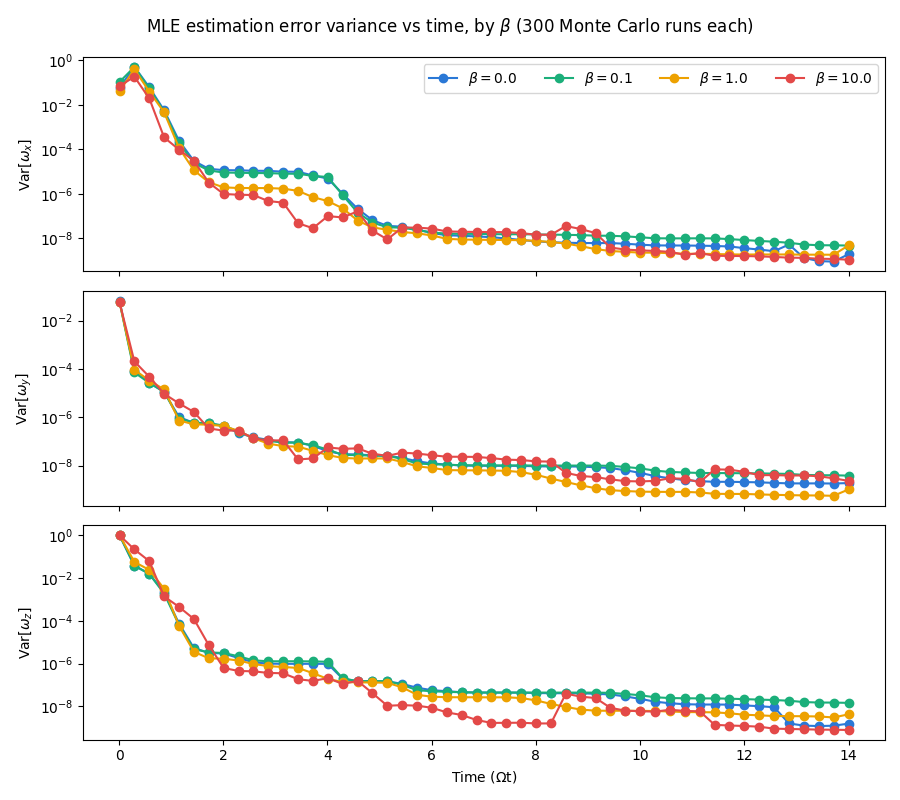

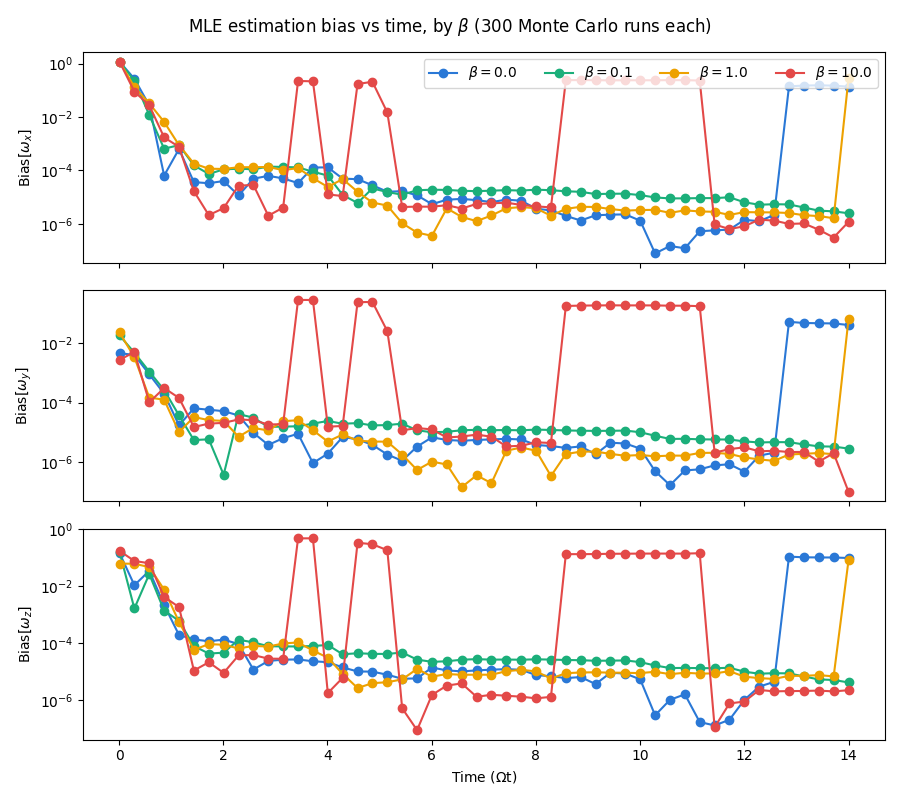

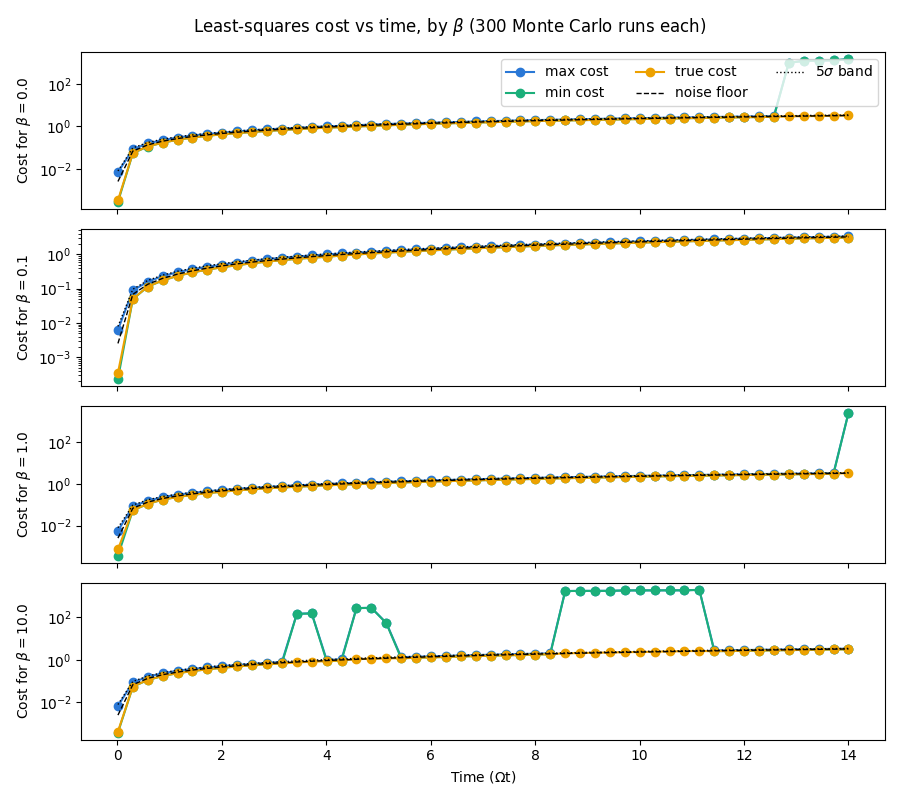

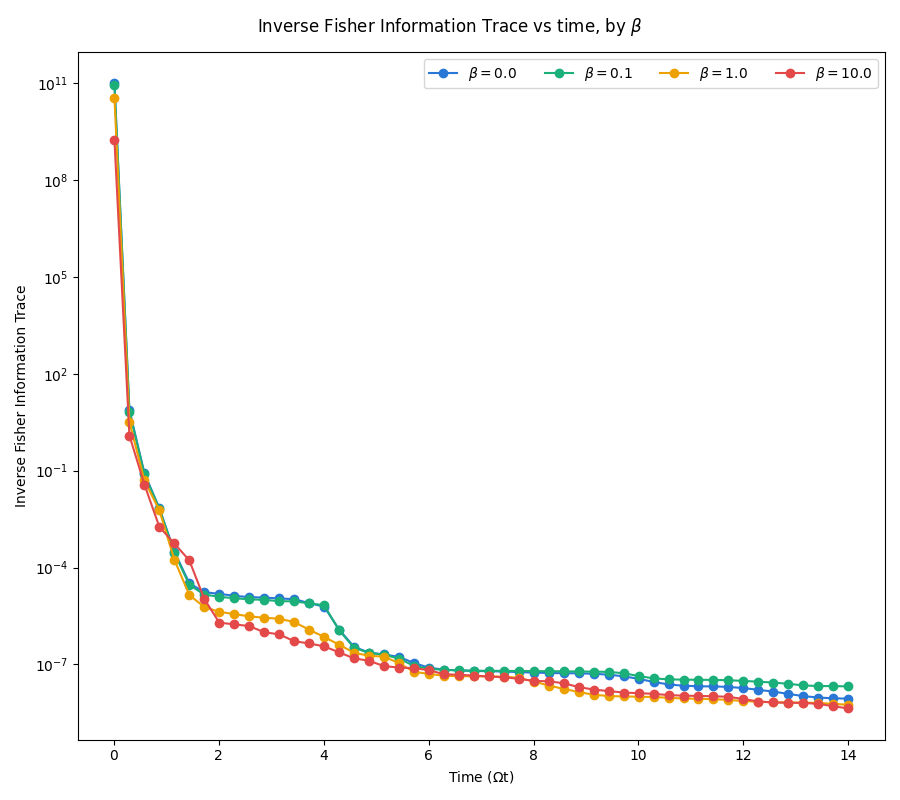

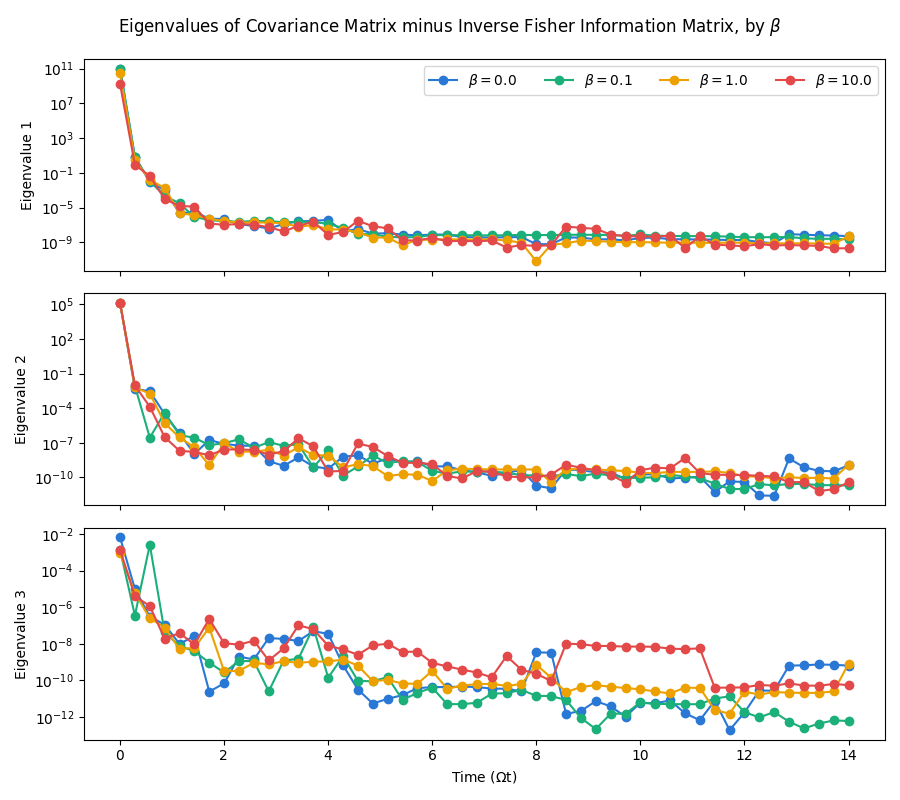

In [48]:
mle_over_time_5 = load_npy(r"C:\Users\alexg\python_scripts\corrected_FI_code\trotter_least_squares_over_time\data_mle_over_time_5")
mle_over_time = mle_over_time_5
labels_omega = [r'$\omega_x$', r'$\omega_y$', r'$\omega_z$']
beta_values = mle_over_time['beta_array']
checkpoint_times = mle_over_time['time_cutoffs_array']
beta_colors = ['#2a78d6', '#1baf7a', '#eda100','#e34948', '#008300', '#4a3aa7',  '#e87ba4', '#eb6834']
dt = 1e-3
omega_true = mle_over_time['w_true']

#Shot-noise cost floor: the residuals at w_true equal the injected noise, so
#E[cost at truth] = 0.5*n_sub*sn_sd^2. Fits whose cost leaves the 5-sigma
#chi-square band converged to a local minimum, not to the global one.
t_steps_run = 14000
n_sub = np.array([np.sum(np.linspace(0, t_steps_run, t_steps_run, dtype=int) <= tc) for tc in checkpoint_times])
sn_sd = 1/(np.sqrt(9.6e8/t_steps_run)*8.9e-7*2e5)
cost_floor = 0.5 * sn_sd**2 * n_sub
cost_band = 0.5 * sn_sd**2 * (n_sub + 5*np.sqrt(2*n_sub))

#Plot variance of MLE estimation error over time for different beta values
fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)
for j, lab in enumerate(labels_omega):
    for b_idx, beta in enumerate(beta_values):
        color = beta_colors[b_idx % len(beta_colors)]
        axes[j].semilogy(checkpoint_times*dt, mle_over_time['std_array'][b_idx][:,j], 'o-',
                            color=color, label=fr'$\beta={beta}$')
    axes[j].set_ylabel(f'Var[{lab}]')
axes[0].legend(loc='upper right', ncol=len(beta_values))
axes[-1].set_xlabel(f'Time ($\Omega$t)')
fig.suptitle(f'MLE estimation error variance vs time, by $\\beta$ (300 Monte Carlo runs each)')
plt.tight_layout()
#plt.savefig(r'C:\Users\alexg\OneDrive\Docs\UNM\Ivan Research\VSCode\Jupyter\plots\data_mle_over_time_1\mle_variance.png', dpi=300, bbox_inches='tight')
plt.show()

#Plot bias of MLE estimation error over time for different beta values
fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)
for j, lab in enumerate(labels_omega):
    for b_idx, beta in enumerate(beta_values):
        color = beta_colors[b_idx % len(beta_colors)]
        axes[j].semilogy(checkpoint_times*dt, np.abs(mle_over_time['bias'][b_idx][:,j]), 'o-',
                            color=color, label=fr'$\beta={beta}$')
    axes[j].set_ylabel(f'Bias[{lab}]')
axes[0].legend(loc='upper right', ncol=len(beta_values))
axes[-1].set_xlabel(f'Time ($\Omega$t)')
fig.suptitle(f'MLE estimation bias vs time, by $\\beta$ (300 Monte Carlo runs each)')
plt.tight_layout()
#plt.savefig(r'C:\Users\alexg\OneDrive\Docs\UNM\Ivan Research\VSCode\Jupyter\plots\data_mle_over_time_1\mle_bias.png', dpi=300, bbox_inches='tight')

plt.show()

#Plot least-squares cost of the kept fits over time for different beta values
#(cost_true is saved as 0.5*||residuals||^2 already; no extra 0.5 factor here)
fig, axes = plt.subplots(len(beta_values), 1, figsize=(9, 8), sharex=True)
for b_idx, beta in enumerate(beta_values):
    color = beta_colors[b_idx % len(beta_colors)]
    axes[b_idx].semilogy(checkpoint_times*dt, mle_over_time['max_cost_estimate'][b_idx][:], 'o-',
                            color=beta_colors[0], label=fr'max cost')
    axes[b_idx].semilogy(checkpoint_times*dt, mle_over_time['min_cost_estimate'][b_idx][:], 'o-',
                            color=beta_colors[1], label=fr'min cost')
    axes[b_idx].semilogy(checkpoint_times*dt, mle_over_time['cost_true'][b_idx][:], 'o-',
                            color=beta_colors[2], label=fr'true cost')
    axes[b_idx].semilogy(checkpoint_times*dt, cost_floor, 'k--', lw=1, label='noise floor')
    axes[b_idx].semilogy(checkpoint_times*dt, cost_band, 'k:', lw=1, label=r'$5\sigma$ band')
    axes[b_idx].set_ylabel(f'Cost for $\\beta = {beta}$')
axes[0].legend(loc='upper right', ncol=3)
axes[-1].set_xlabel(f'Time ($\Omega$t)')
fig.suptitle(f'Least-squares cost vs time, by $\\beta$ (300 Monte Carlo runs each)')
plt.tight_layout()
#plt.savefig(r'C:\Users\alexg\OneDrive\Docs\UNM\Ivan Research\VSCode\Jupyter\plots\data_mle_over_time_1\mle_bias.png', dpi=300, bbox_inches='tight')

plt.show()

#Plot Trace of inverse Fisher Information over time for different beta values
fig, axes = plt.subplots(1, 1, figsize=(9, 8), sharex=True)
for b_idx, beta in enumerate(beta_values):
    color = beta_colors[b_idx % len(beta_colors)]
    axes.semilogy(checkpoint_times*dt, mle_over_time['fisher_inv_trace'][b_idx][:], 'o-',
                            color=color, label=fr'$\beta={beta}$')
    axes.set_ylabel(f'Inverse Fisher Information Trace')
axes.legend(loc='upper right', ncol=len(beta_values))
axes.set_xlabel(f'Time ($\Omega$t)')
fig.suptitle(f'Inverse Fisher Information Trace vs time, by $\\beta$')
plt.tight_layout()
#plt.savefig(r'C:\Users\alexg\OneDrive\Docs\UNM\Ivan Research\VSCode\Jupyter\plots\data_mle_over_time_1\mle_bias.png', dpi=300, bbox_inches='tight')

plt.show()


#Plot Trace of inverse Fisher Information over time for different beta values
fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)
for j in range(3):
    for b_idx, beta in enumerate(beta_values):
        color = beta_colors[b_idx % len(beta_colors)]
        axes[j].semilogy(checkpoint_times*dt, np.abs(mle_over_time['CRB_diff_eig'][b_idx][:,j]), 'o-',
                                color=color, label=fr'$\beta={beta}$')
        axes[j].set_ylabel(f'Eigenvalue {j+1}')
axes[0].legend(loc='upper right', ncol=len(beta_values))
axes[-1].set_xlabel(f'Time ($\Omega$t)')
fig.suptitle(f'Eigenvalues of Covariance Matrix minus Inverse Fisher Information Matrix, by $\\beta$')
plt.tight_layout()
#plt.savefig(r'C:\Users\alexg\OneDrive\Docs\UNM\Ivan Research\VSCode\Jupyter\plots\data_mle_over_time_1\mle_bias.png', dpi=300, bbox_inches='tight')

plt.show()


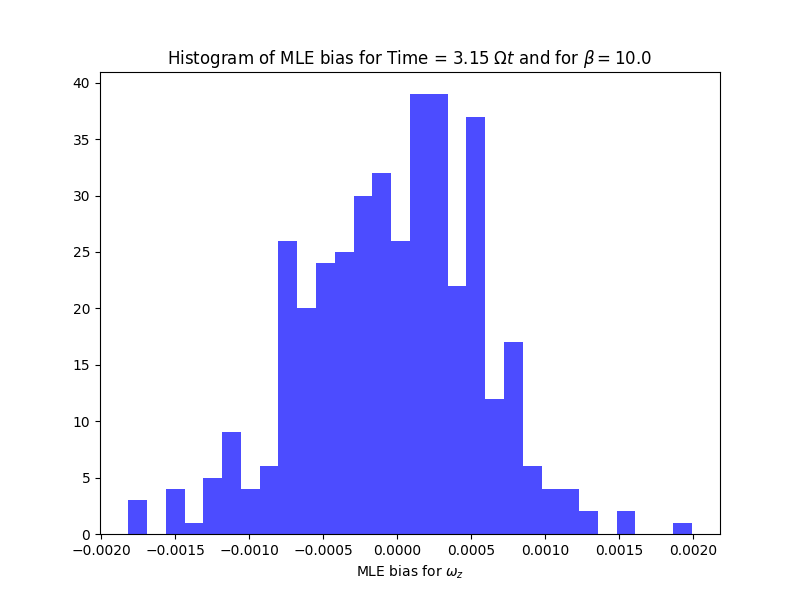

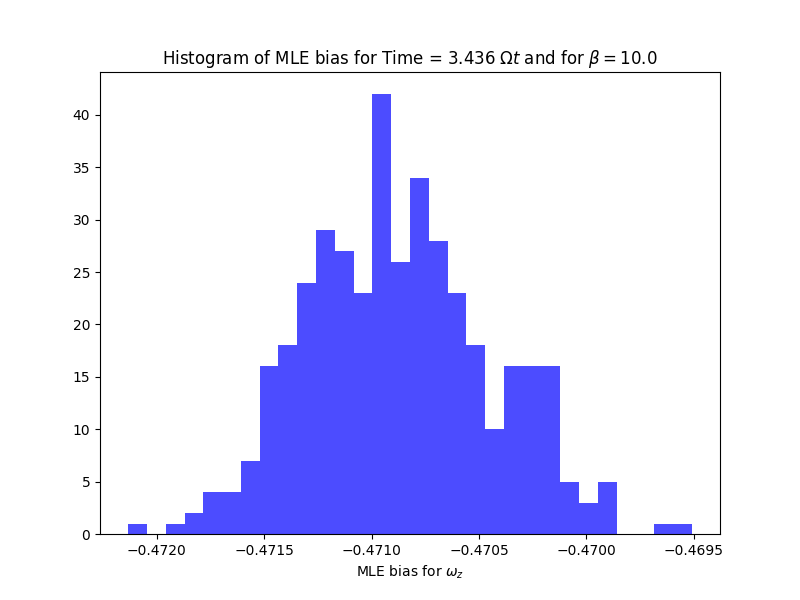

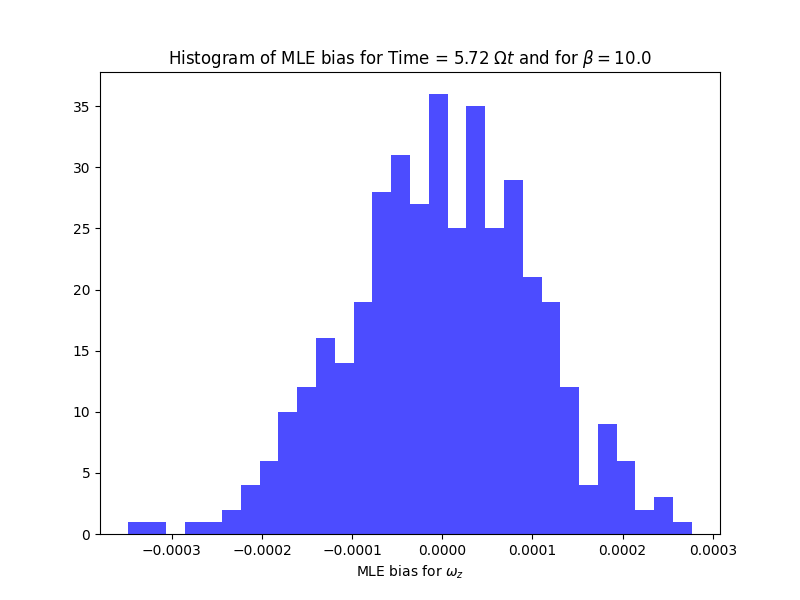

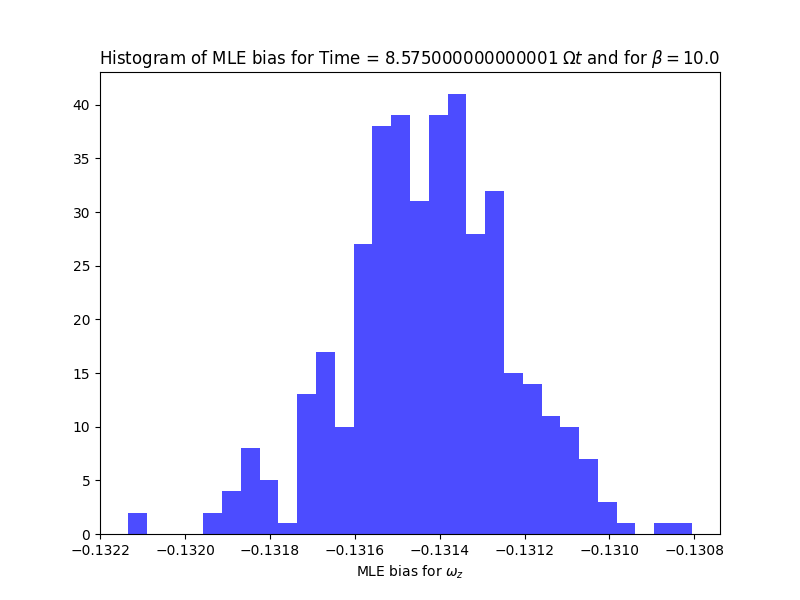

In [44]:
#w_est_over_time holds the beta = 10 fits: its per-cutoff mean reproduces mean_array[3] exactly
w_est5 = mle_over_time_5['w_est_over_time']      # (n_time, n_fits, 3)
w_true5 = mle_over_time_5['w_true']
cutoffs5 = mle_over_time_5['time_cutoffs_array']

for time_index in [11, 12, 20, 30]:
    plt.figure(figsize=(8, 6))
    plt.hist(w_est5[time_index,:,2] - w_true5[2], bins=30, density=False, alpha=0.7, color='blue')
    plt.title(f'Histogram of MLE bias for Time = ${cutoffs5[time_index]*dt} \; \Omega t$ and for $\\beta = {mle_over_time_5["beta_array"][3]}$')
    plt.xlabel(f'MLE bias for $\\omega_z$')
    plt.show()

## Diagnostics: are the bias/cost spikes optimizer failures?

Mechanism under test: each fit starts from a **single** random point uniform in $[-1,1]^3$, but the global least-squares basin around $\omega_{true}$ ($|\omega_{true}| \sim 0.1$–$0.3$) narrows as the fit window grows, so more and more starts end in **local minima**. At some cutoffs a large share (even a majority) of the fits land in the *same* wrong basin: the variance stays small (the wrong cluster is tight) while the mean jumps (bias spike), and the max cost jumps far above the shot-noise floor — exactly the correlated bias/cost spikes seen above. (The current script additionally keeps only the lowest-cost 250 of 500 fits, which makes the wrong-cluster selection even cleaner; the folder-5 run kept all 400.)

- **D1** — pairwise scatters of the kept fits at spike vs quiet cutoffs (multimodality check)
- **D2/D3** — fraction of fits far from $\omega_{true}$ / stuck at the $\pm 1$ bounds, overlaid on the bias curve
- **D4** — covered in the cost figure above: max/min cost vs the $\tfrac{1}{2} n \sigma^2$ noise floor and $5\sigma$ chi-square band
- **D5** — full-sample mean vs median vs mean of the near-$\omega_{true}$ subset (a smooth near-subset mean plus a spiky full mean confirms contamination)

Note: `w_est_over_time` holds only the $\beta = 10$ fits (its per-cutoff mean reproduces `mean_array[3]` to machine precision).

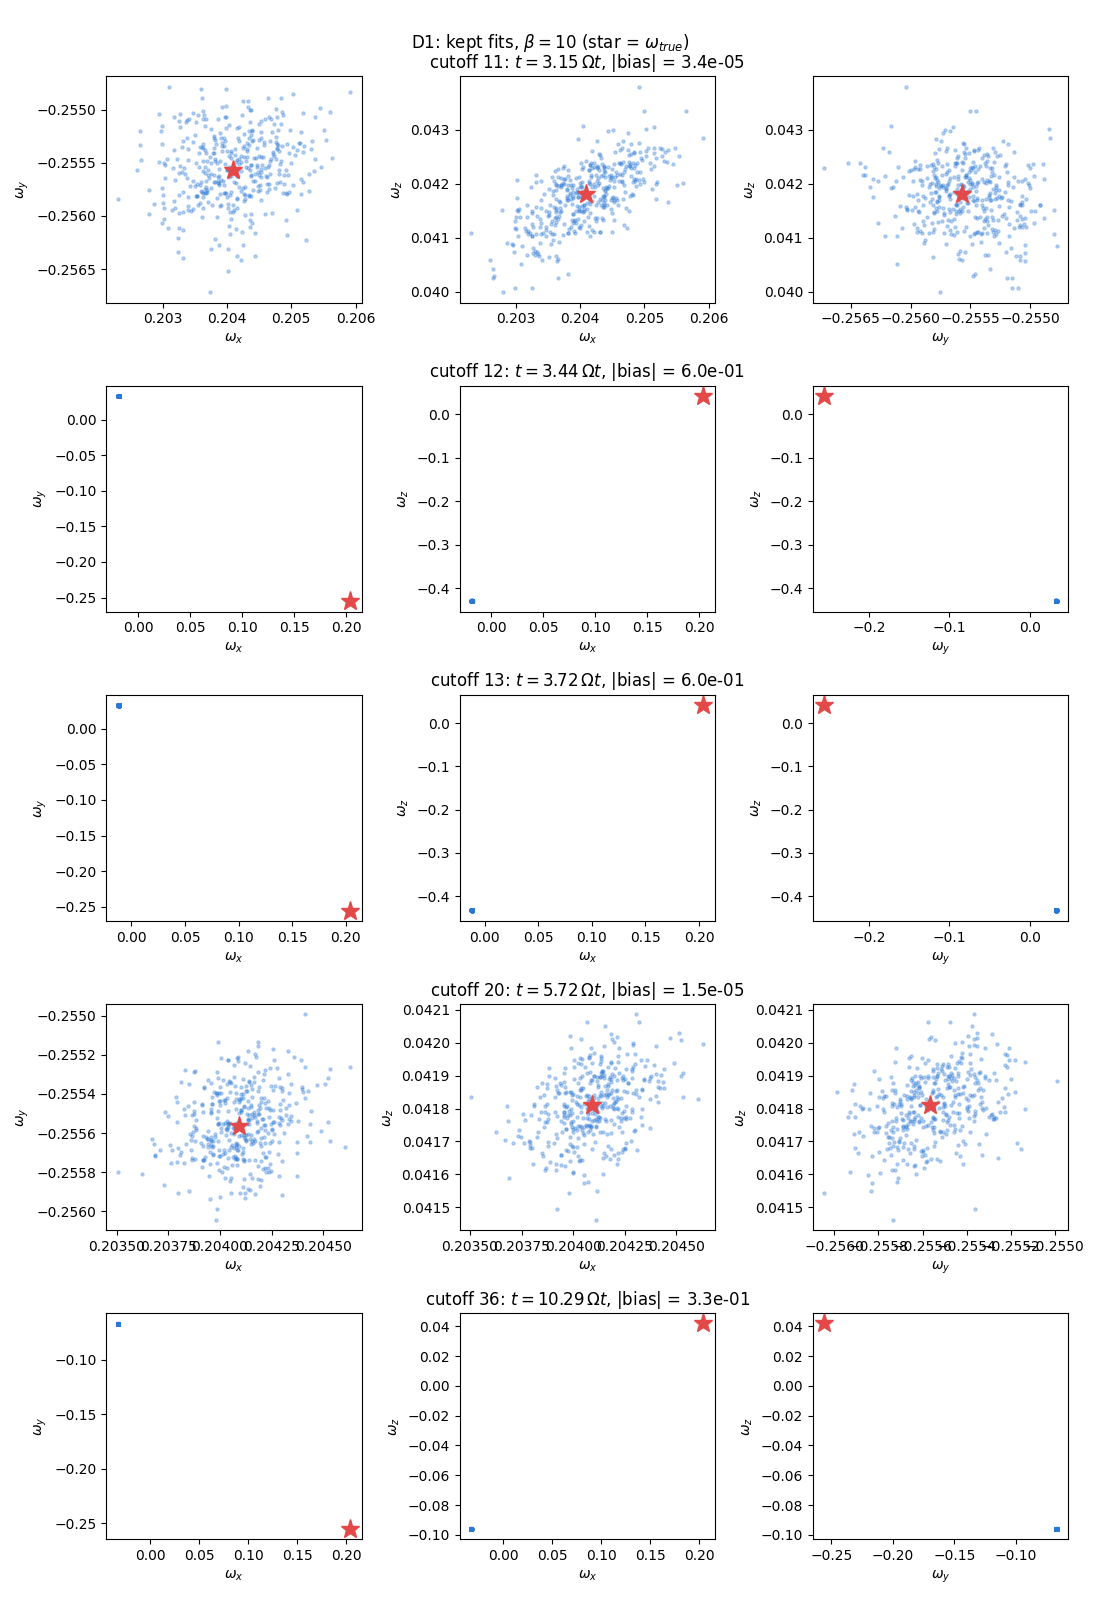

In [45]:
# D1: pairwise scatters of all kept fits at bias-spike cutoffs (12, 13) vs quiet ones (11, 20)
# and a late spike (36). Discrete clusters away from w_true = local minima of the cost.
pairs = [(0, 1), (0, 2), (1, 2)]
show_idx = [11, 12, 13, 20, 36]
bias_norm5 = np.linalg.norm(mle_over_time_5['bias'][3], axis=1)

fig, axes = plt.subplots(len(show_idx), len(pairs), figsize=(11, 3.2*len(show_idx)))
for r, ti in enumerate(show_idx):
    for c, (i, j) in enumerate(pairs):
        ax = axes[r, c]
        ax.scatter(w_est5[ti, :, i], w_est5[ti, :, j], s=5, alpha=0.3, color=beta_colors[0])
        ax.plot(w_true5[i], w_true5[j], '*', color=beta_colors[3], markersize=14)
        ax.set_xlabel(labels_omega[i])
        ax.set_ylabel(labels_omega[j])
    axes[r, 1].set_title(f'cutoff {ti}: $t = {cutoffs5[ti]*dt:.2f}\\,\\Omega t$, |bias| = {bias_norm5[ti]:.1e}')
fig.suptitle(r'D1: kept fits, $\beta = 10$ (star = $\omega_{true}$)')
plt.tight_layout()
plt.show()

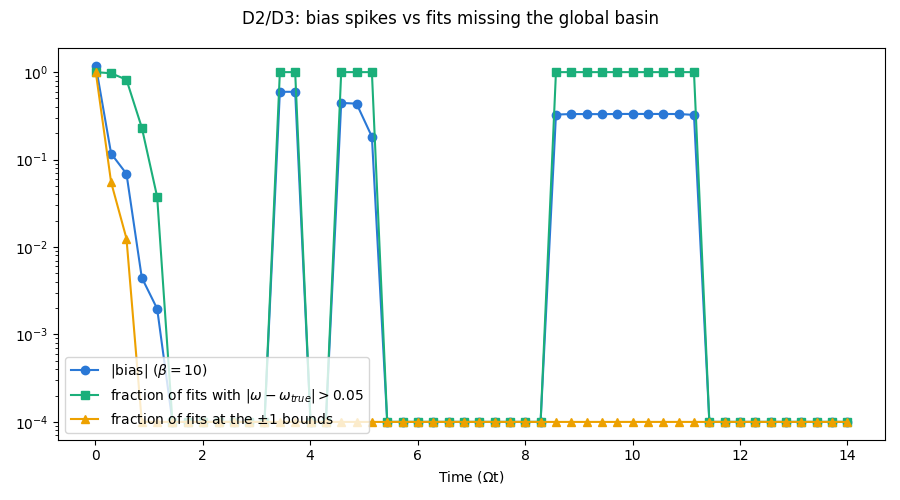

cutoff idxs where >5% of kept fits miss the global basin: [0, 1, 2, 3, 12, 13, 16, 17, 18, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]
cutoff idxs where max cost exceeds the 5-sigma band:     [12, 13, 16, 17, 18, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]


In [46]:
# D2/D3: fraction of fits that missed the global basin (or sit at the +-1 bounds),
# overlaid on the bias curve. The bias spikes should coincide with dips in basin capture.
bias_norm5 = np.linalg.norm(mle_over_time_5['bias'][3], axis=1)
frac_far = np.mean(np.linalg.norm(w_est5 - w_true5, axis=2) > 0.05, axis=1)
frac_bound = np.mean(np.max(np.abs(w_est5), axis=2) > 0.99, axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
eps = 1e-4  # keep zeros visible on the log axis
ax.semilogy(cutoffs5*dt, np.maximum(bias_norm5, eps), 'o-', color=beta_colors[0],
            label=r'$|\mathrm{bias}|$ ($\beta = 10$)')
ax.semilogy(cutoffs5*dt, np.maximum(frac_far, eps), 's-', color=beta_colors[1],
            label=r'fraction of fits with $|\omega - \omega_{true}| > 0.05$')
ax.semilogy(cutoffs5*dt, np.maximum(frac_bound, eps), '^-', color=beta_colors[2],
            label=r'fraction of fits at the $\pm 1$ bounds')
ax.set_xlabel(f'Time ($\Omega$t)')
ax.legend(loc='lower left')
fig.suptitle('D2/D3: bias spikes vs fits missing the global basin')
plt.tight_layout()
plt.show()

print('cutoff idxs where >5% of kept fits miss the global basin:',
      np.where(frac_far > 0.05)[0].tolist())
print('cutoff idxs where max cost exceeds the 5-sigma band:    ',
      np.where(mle_over_time_5['max_cost_estimate'][3] > cost_band)[0].tolist())

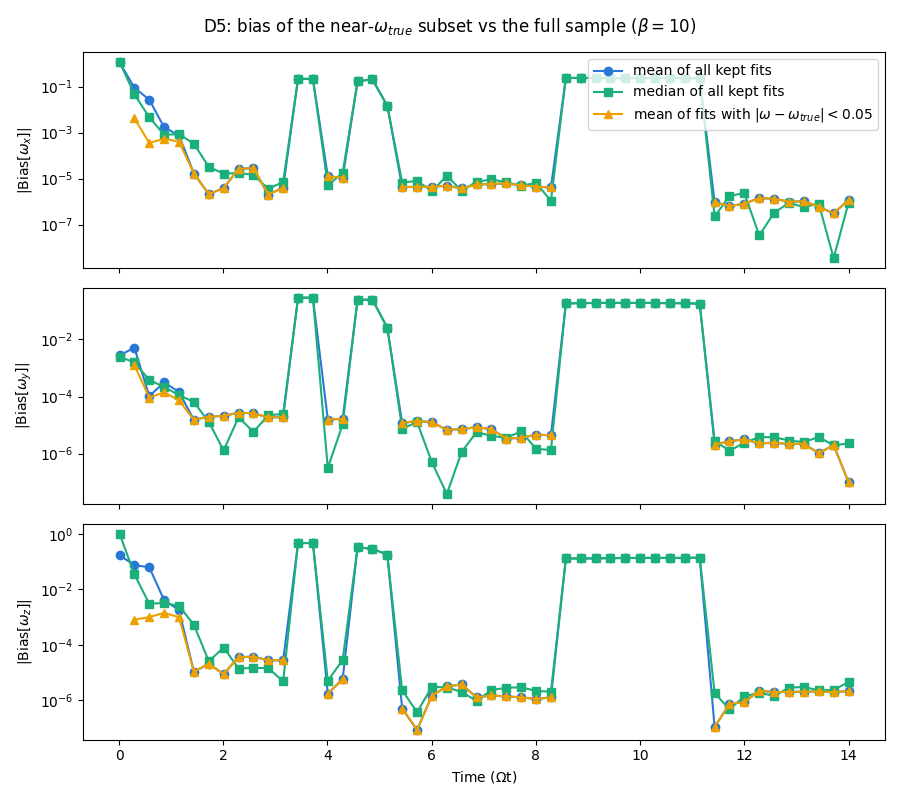

In [47]:
# D5: full-sample mean vs median vs mean of only the fits that found the global basin.
# If the near-subset mean stays smooth where the full mean spikes, the bias spikes are
# contamination by wrong-basin fits, not a property of the estimator itself.
near = np.linalg.norm(w_est5 - w_true5, axis=2) < 0.05          # (n_time, n_fits)
mean_all = w_est5.mean(axis=1)
median_all = np.median(w_est5, axis=1)
mean_near = np.array([w_est5[j, near[j]].mean(axis=0) if near[j].any() else np.full(3, np.nan)
                      for j in range(len(cutoffs5))])

fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)
for k, lab in enumerate(labels_omega):
    axes[k].semilogy(cutoffs5*dt, np.abs(mean_all[:, k] - w_true5[k]), 'o-',
                     color=beta_colors[0], label='mean of all kept fits')
    axes[k].semilogy(cutoffs5*dt, np.abs(median_all[:, k] - w_true5[k]), 's-',
                     color=beta_colors[1], label='median of all kept fits')
    axes[k].semilogy(cutoffs5*dt, np.abs(mean_near[:, k] - w_true5[k]), '^-',
                     color=beta_colors[2], label=r'mean of fits with $|\omega - \omega_{true}| < 0.05$')
    axes[k].set_ylabel(f'|Bias[{lab}]|')
axes[0].legend(loc='upper right')
axes[-1].set_xlabel(f'Time ($\Omega$t)')
fig.suptitle(r'D5: bias of the near-$\omega_{true}$ subset vs the full sample ($\beta = 10$)')
plt.tight_layout()
plt.show()

MLE over time 6 (rng = 3, initializing from random parameters within [-1,1] and only picking lowest cost function outputs)

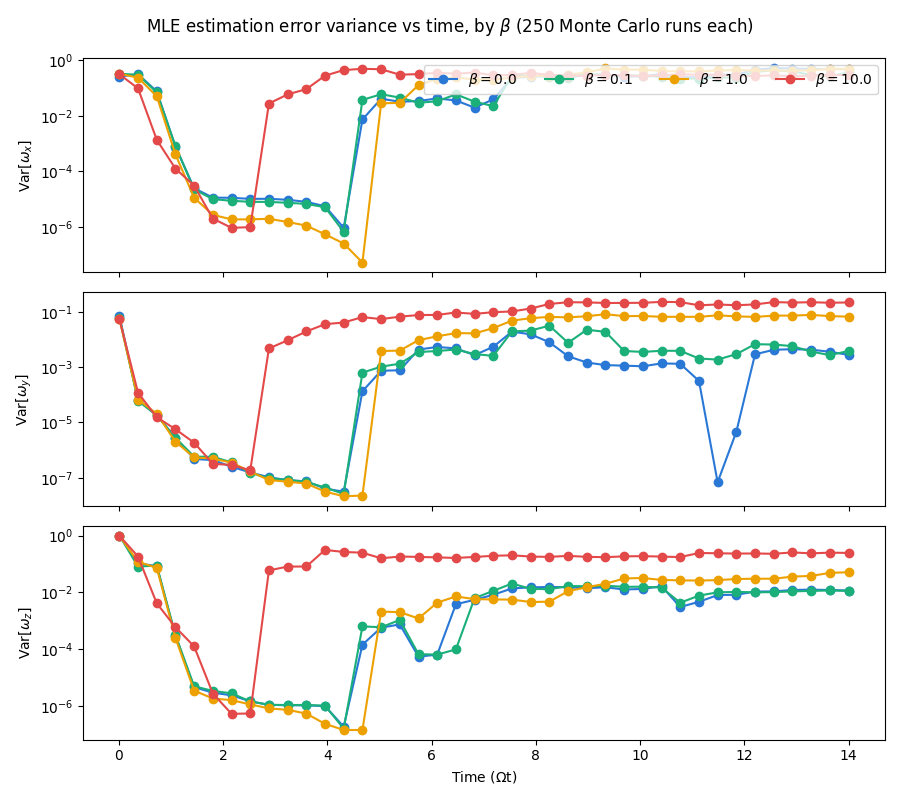

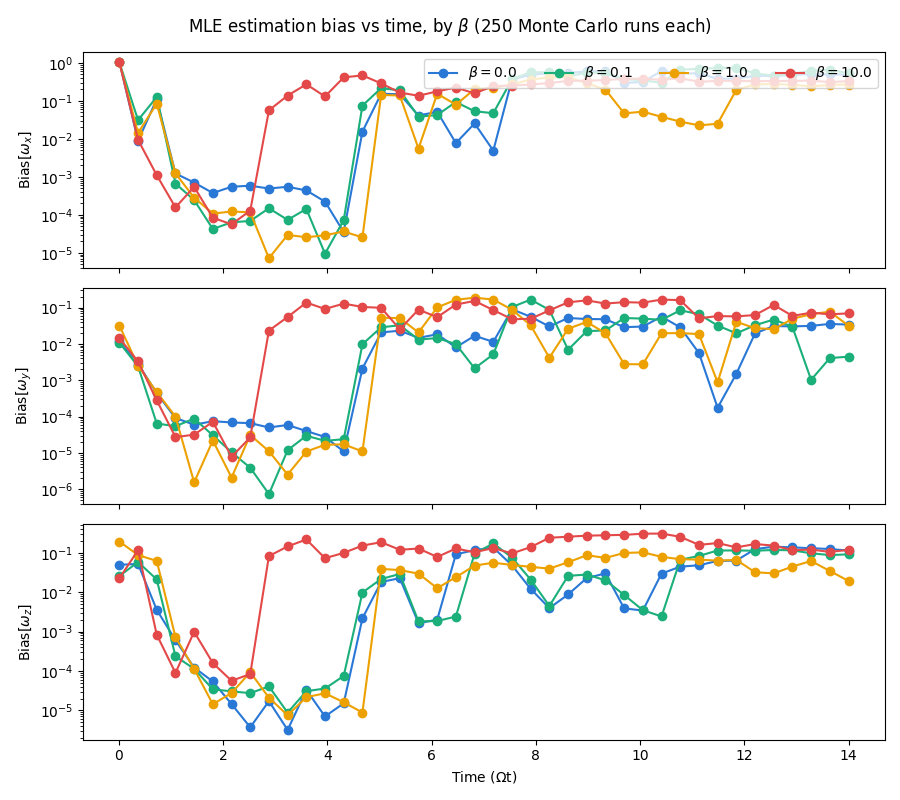

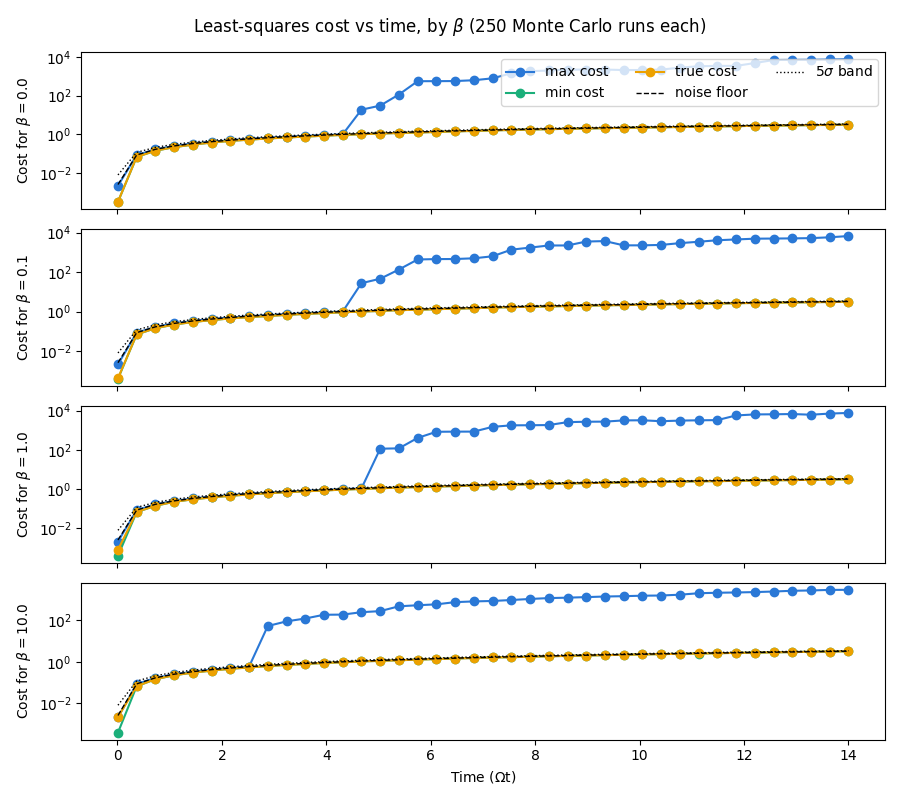

C:\Users\alexg\AppData\Local\Temp\ipykernel_26856\445234143.py:73: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, axes = plt.subplots(1, 1, figsize=(9, 8), sharex=True)


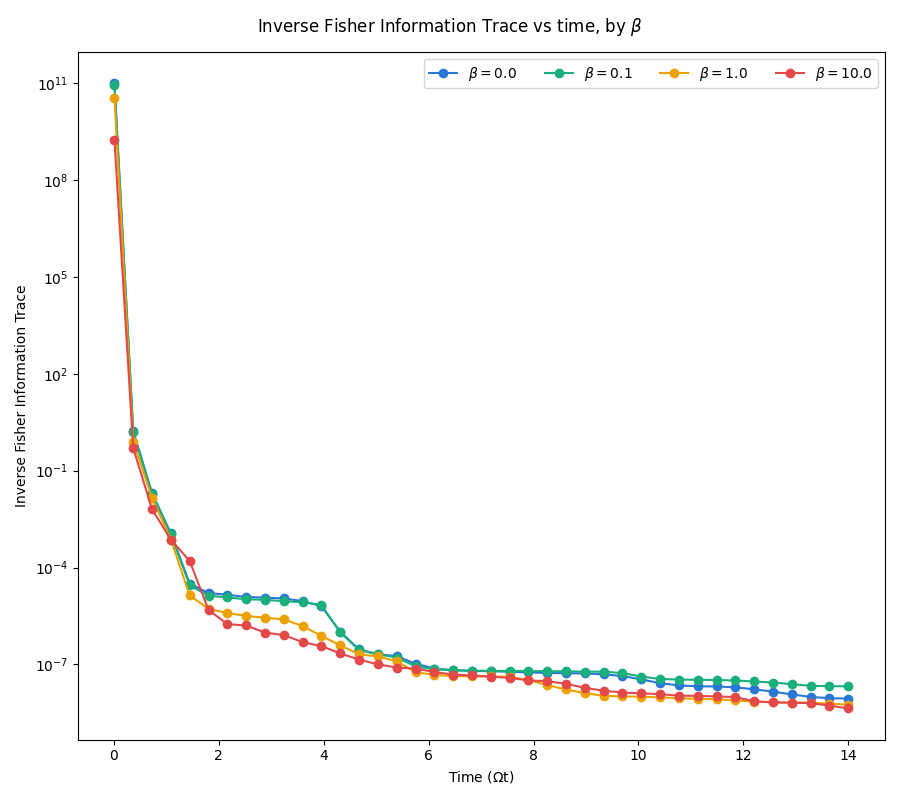

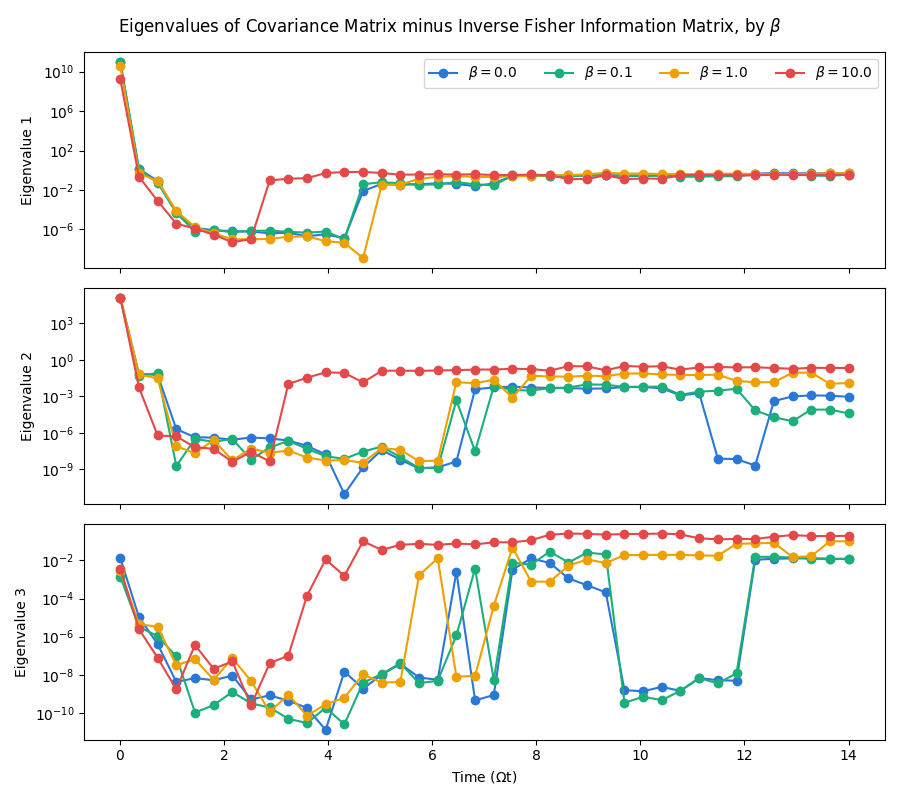

In [50]:
mle_over_time_6 = load_npy(r"C:\Users\alexg\python_scripts\corrected_FI_code\trotter_least_squares_over_time\data_mle_over_time_6")
mle_over_time = mle_over_time_6
labels_omega = [r'$\omega_x$', r'$\omega_y$', r'$\omega_z$']
beta_values = mle_over_time['beta_array']
checkpoint_times = mle_over_time['time_cutoffs_array']
beta_colors = ['#2a78d6', '#1baf7a', '#eda100','#e34948', '#008300', '#4a3aa7',  '#e87ba4', '#eb6834']
dt = 1e-3
omega_true = mle_over_time['w_true']

#Shot-noise cost floor: the residuals at w_true equal the injected noise, so
#E[cost at truth] = 0.5*n_sub*sn_sd^2. Fits whose cost leaves the 5-sigma
#chi-square band converged to a local minimum, not to the global one.
t_steps_run = 14000
n_sub = np.array([np.sum(np.linspace(0, t_steps_run, t_steps_run, dtype=int) <= tc) for tc in checkpoint_times])
sn_sd = 1/(np.sqrt(9.6e8/t_steps_run)*8.9e-7*2e5)
cost_floor = 0.5 * sn_sd**2 * n_sub
cost_band = 0.5 * sn_sd**2 * (n_sub + 5*np.sqrt(2*n_sub))

#Plot variance of MLE estimation error over time for different beta values
fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)
for j, lab in enumerate(labels_omega):
    for b_idx, beta in enumerate(beta_values):
        color = beta_colors[b_idx % len(beta_colors)]
        axes[j].semilogy(checkpoint_times*dt, mle_over_time['std_array'][b_idx][:,j], 'o-',
                            color=color, label=fr'$\beta={beta}$')
    axes[j].set_ylabel(f'Var[{lab}]')
axes[0].legend(loc='upper right', ncol=len(beta_values))
axes[-1].set_xlabel(f'Time ($\Omega$t)')
fig.suptitle(f'MLE estimation error variance vs time, by $\\beta$ (250 Monte Carlo runs each)')
plt.tight_layout()
#plt.savefig(r'C:\Users\alexg\OneDrive\Docs\UNM\Ivan Research\VSCode\Jupyter\plots\data_mle_over_time_1\mle_variance.png', dpi=300, bbox_inches='tight')
plt.show()

#Plot bias of MLE estimation error over time for different beta values
fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)
for j, lab in enumerate(labels_omega):
    for b_idx, beta in enumerate(beta_values):
        color = beta_colors[b_idx % len(beta_colors)]
        axes[j].semilogy(checkpoint_times*dt, np.abs(mle_over_time['bias'][b_idx][:,j]), 'o-',
                            color=color, label=fr'$\beta={beta}$')
    axes[j].set_ylabel(f'Bias[{lab}]')
axes[0].legend(loc='upper right', ncol=len(beta_values))
axes[-1].set_xlabel(f'Time ($\Omega$t)')
fig.suptitle(f'MLE estimation bias vs time, by $\\beta$ (250 Monte Carlo runs each)')
plt.tight_layout()
#plt.savefig(r'C:\Users\alexg\OneDrive\Docs\UNM\Ivan Research\VSCode\Jupyter\plots\data_mle_over_time_1\mle_bias.png', dpi=300, bbox_inches='tight')

plt.show()

#Plot least-squares cost of the kept fits over time for different beta values
#(cost_true is saved as 0.5*||residuals||^2 already; no extra 0.5 factor here)
fig, axes = plt.subplots(len(beta_values), 1, figsize=(9, 8), sharex=True)
for b_idx, beta in enumerate(beta_values):
    color = beta_colors[b_idx % len(beta_colors)]
    axes[b_idx].semilogy(checkpoint_times*dt, mle_over_time['max_cost_estimate'][b_idx][:], 'o-',
                            color=beta_colors[0], label=fr'max cost')
    axes[b_idx].semilogy(checkpoint_times*dt, mle_over_time['min_cost_estimate'][b_idx][:], 'o-',
                            color=beta_colors[1], label=fr'min cost')
    axes[b_idx].semilogy(checkpoint_times*dt, mle_over_time['cost_true'][b_idx][:], 'o-',
                            color=beta_colors[2], label=fr'true cost')
    axes[b_idx].semilogy(checkpoint_times*dt, cost_floor, 'k--', lw=1, label='noise floor')
    axes[b_idx].semilogy(checkpoint_times*dt, cost_band, 'k:', lw=1, label=r'$5\sigma$ band')
    axes[b_idx].set_ylabel(f'Cost for $\\beta = {beta}$')
axes[0].legend(loc='upper right', ncol=3)
axes[-1].set_xlabel(f'Time ($\Omega$t)')
fig.suptitle(f'Least-squares cost vs time, by $\\beta$ (250 Monte Carlo runs each)')
plt.tight_layout()
#plt.savefig(r'C:\Users\alexg\OneDrive\Docs\UNM\Ivan Research\VSCode\Jupyter\plots\data_mle_over_time_1\mle_bias.png', dpi=300, bbox_inches='tight')

plt.show()

#Plot Trace of inverse Fisher Information over time for different beta values
fig, axes = plt.subplots(1, 1, figsize=(9, 8), sharex=True)
for b_idx, beta in enumerate(beta_values):
    color = beta_colors[b_idx % len(beta_colors)]
    axes.semilogy(checkpoint_times*dt, mle_over_time['fisher_inv_trace'][b_idx][:], 'o-',
                            color=color, label=fr'$\beta={beta}$')
    axes.set_ylabel(f'Inverse Fisher Information Trace')
axes.legend(loc='upper right', ncol=len(beta_values))
axes.set_xlabel(f'Time ($\Omega$t)')
fig.suptitle(f'Inverse Fisher Information Trace vs time, by $\\beta$')
plt.tight_layout()
#plt.savefig(r'C:\Users\alexg\OneDrive\Docs\UNM\Ivan Research\VSCode\Jupyter\plots\data_mle_over_time_1\mle_bias.png', dpi=300, bbox_inches='tight')

plt.show()


#Plot Trace of inverse Fisher Information over time for different beta values
fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)
for j in range(3):
    for b_idx, beta in enumerate(beta_values):
        color = beta_colors[b_idx % len(beta_colors)]
        axes[j].semilogy(checkpoint_times*dt, np.abs(mle_over_time['CRB_diff_eig'][b_idx][:,j]), 'o-',
                                color=color, label=fr'$\beta={beta}$')
        axes[j].set_ylabel(f'Eigenvalue {j+1}')
axes[0].legend(loc='upper right', ncol=len(beta_values))
axes[-1].set_xlabel(f'Time ($\Omega$t)')
fig.suptitle(f'Eigenvalues of Covariance Matrix minus Inverse Fisher Information Matrix, by $\\beta$')
plt.tight_layout()
#plt.savefig(r'C:\Users\alexg\OneDrive\Docs\UNM\Ivan Research\VSCode\Jupyter\plots\data_mle_over_time_1\mle_bias.png', dpi=300, bbox_inches='tight')

plt.show()


MLE over time 7 (rng = 3, claude updated code which does warm start)

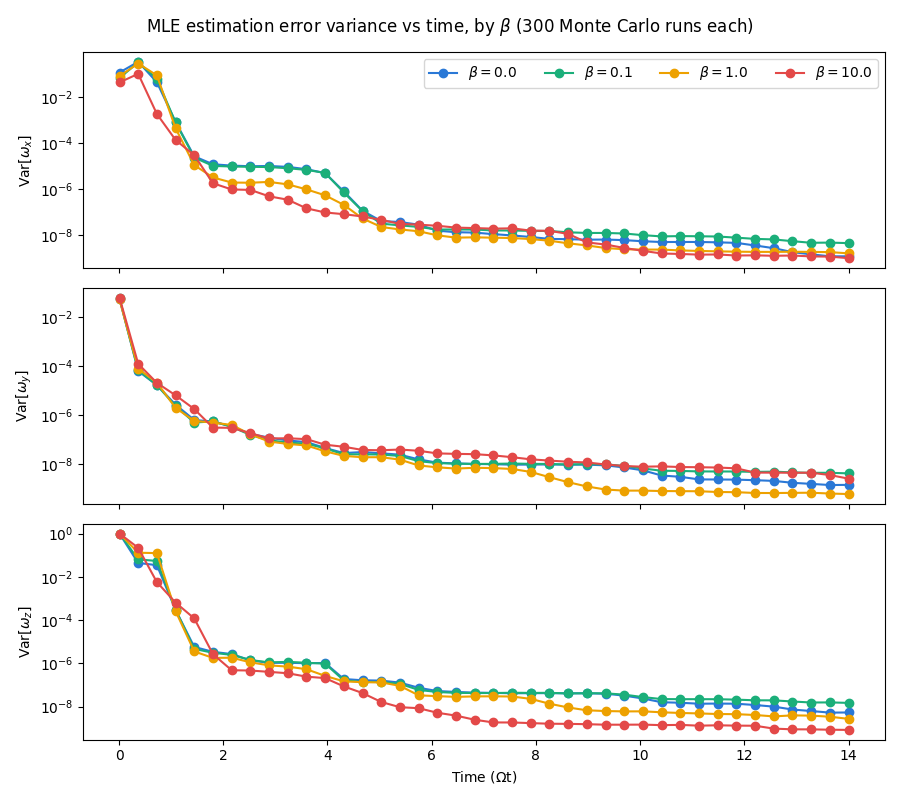

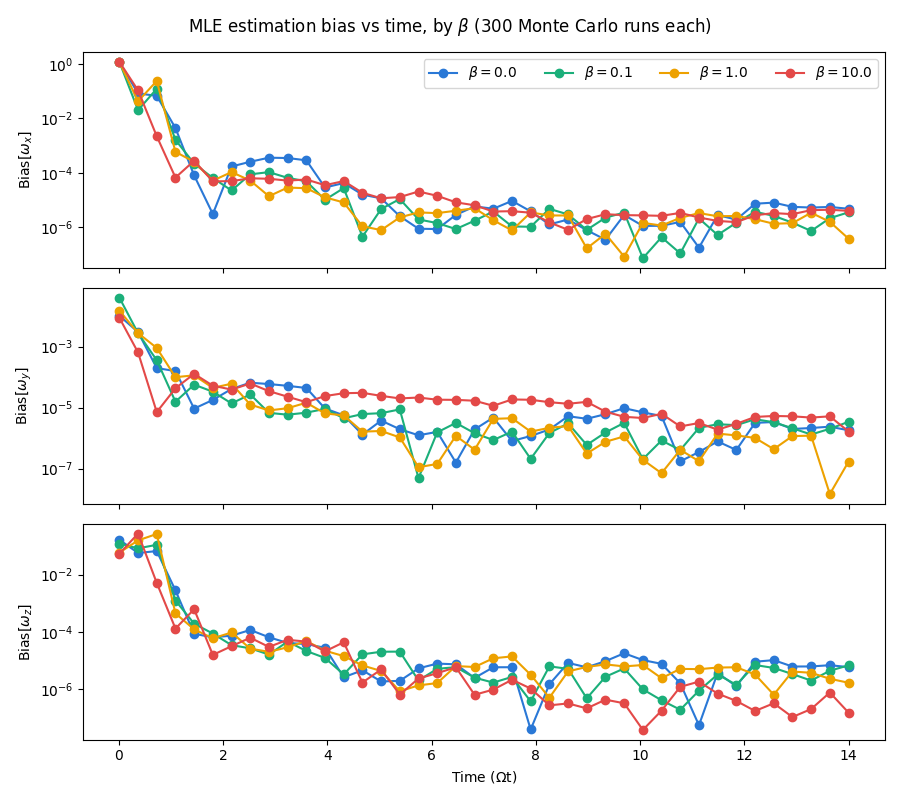

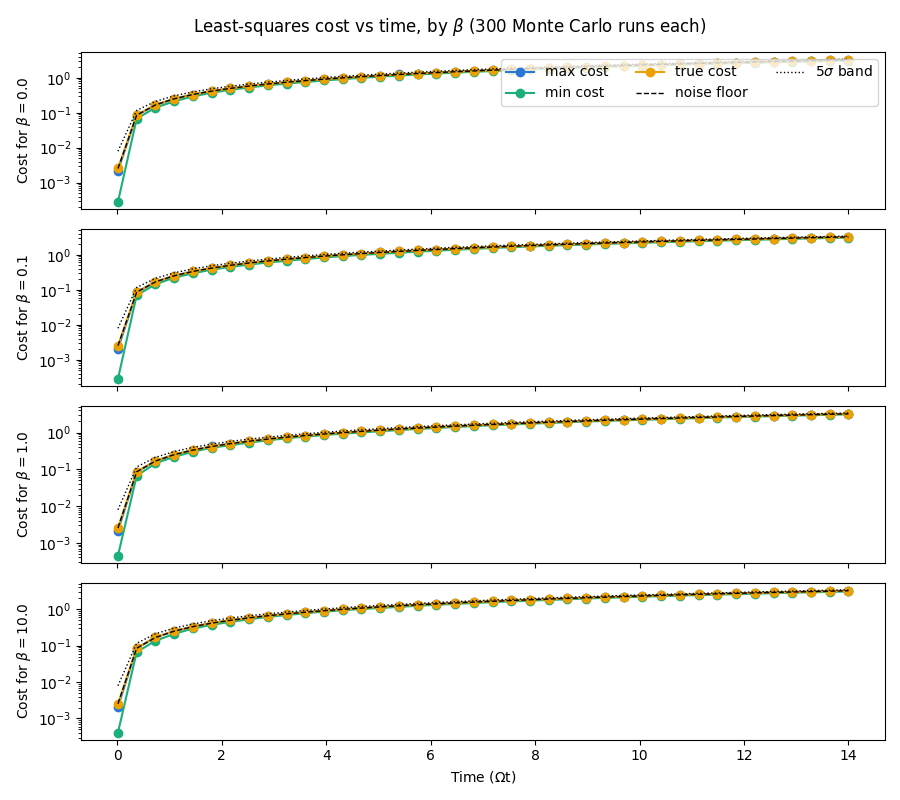

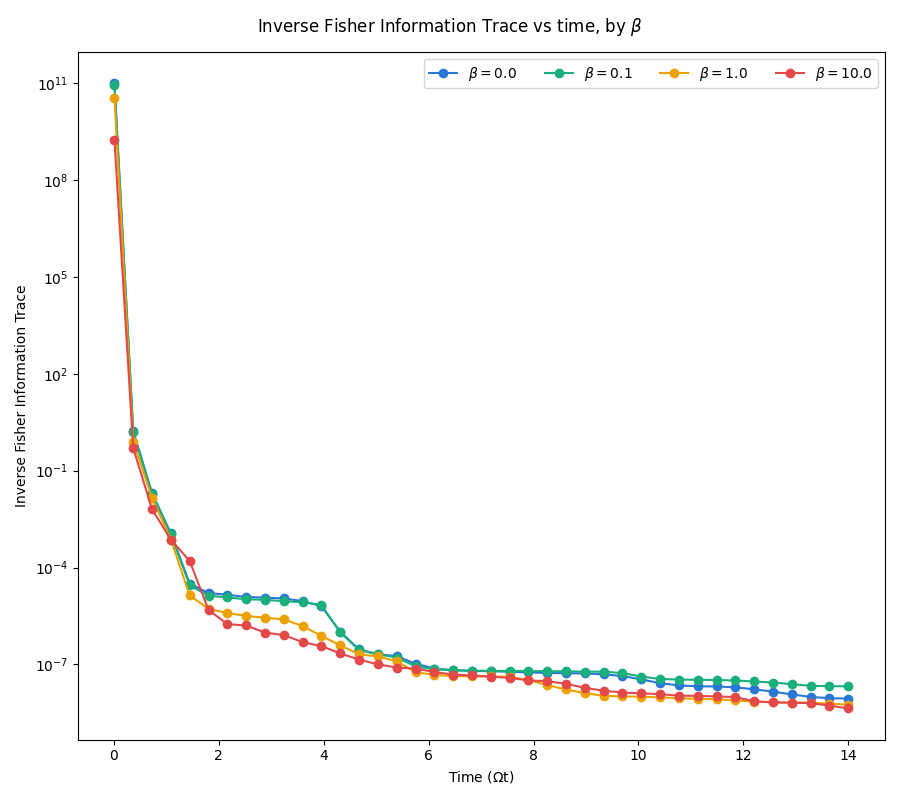

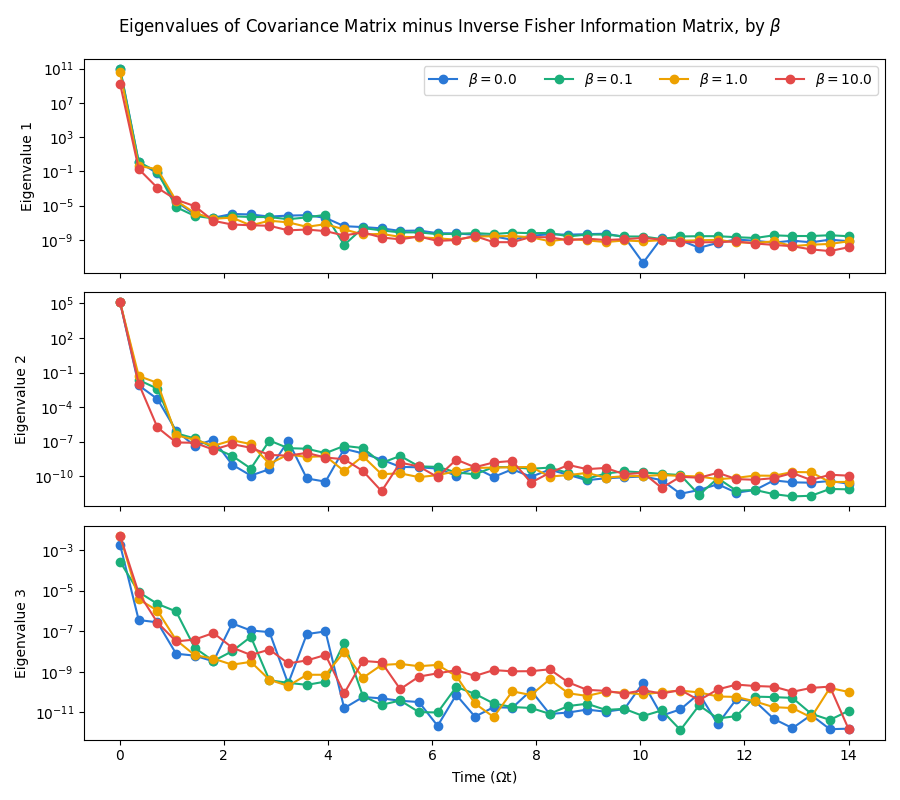

In [51]:
mle_over_time_7 = load_npy(r"C:\Users\alexg\python_scripts\corrected_FI_code\trotter_least_squares_over_time\data_mle_over_time_7")
mle_over_time = mle_over_time_7
labels_omega = [r'$\omega_x$', r'$\omega_y$', r'$\omega_z$']
beta_values = mle_over_time['beta_array']
checkpoint_times = mle_over_time['time_cutoffs_array']
beta_colors = ['#2a78d6', '#1baf7a', '#eda100','#e34948', '#008300', '#4a3aa7',  '#e87ba4', '#eb6834']
dt = 1e-3
omega_true = mle_over_time['w_true']

#Shot-noise cost floor: the residuals at w_true equal the injected noise, so
#E[cost at truth] = 0.5*n_sub*sn_sd^2. Fits whose cost leaves the 5-sigma
#chi-square band converged to a local minimum, not to the global one.
t_steps_run = 14000
n_sub = np.array([np.sum(np.linspace(0, t_steps_run, t_steps_run, dtype=int) <= tc) for tc in checkpoint_times])
sn_sd = 1/(np.sqrt(9.6e8/t_steps_run)*8.9e-7*2e5)
cost_floor = 0.5 * sn_sd**2 * n_sub
cost_band = 0.5 * sn_sd**2 * (n_sub + 5*np.sqrt(2*n_sub))

#Plot variance of MLE estimation error over time for different beta values
fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)
for j, lab in enumerate(labels_omega):
    for b_idx, beta in enumerate(beta_values):
        color = beta_colors[b_idx % len(beta_colors)]
        axes[j].semilogy(checkpoint_times*dt, mle_over_time['std_array'][b_idx][:,j], 'o-',
                            color=color, label=fr'$\beta={beta}$')
    axes[j].set_ylabel(f'Var[{lab}]')
axes[0].legend(loc='upper right', ncol=len(beta_values))
axes[-1].set_xlabel(f'Time ($\Omega$t)')
fig.suptitle(f'MLE estimation error variance vs time, by $\\beta$ (300 Monte Carlo runs each)')
plt.tight_layout()
#plt.savefig(r'C:\Users\alexg\OneDrive\Docs\UNM\Ivan Research\VSCode\Jupyter\plots\data_mle_over_time_1\mle_variance.png', dpi=300, bbox_inches='tight')
plt.show()

#Plot bias of MLE estimation error over time for different beta values
fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)
for j, lab in enumerate(labels_omega):
    for b_idx, beta in enumerate(beta_values):
        color = beta_colors[b_idx % len(beta_colors)]
        axes[j].semilogy(checkpoint_times*dt, np.abs(mle_over_time['bias'][b_idx][:,j]), 'o-',
                            color=color, label=fr'$\beta={beta}$')
    axes[j].set_ylabel(f'Bias[{lab}]')
axes[0].legend(loc='upper right', ncol=len(beta_values))
axes[-1].set_xlabel(f'Time ($\Omega$t)')
fig.suptitle(f'MLE estimation bias vs time, by $\\beta$ (300 Monte Carlo runs each)')
plt.tight_layout()
#plt.savefig(r'C:\Users\alexg\OneDrive\Docs\UNM\Ivan Research\VSCode\Jupyter\plots\data_mle_over_time_1\mle_bias.png', dpi=300, bbox_inches='tight')

plt.show()

#Plot least-squares cost of the kept fits over time for different beta values
#(cost_true is saved as 0.5*||residuals||^2 already; no extra 0.5 factor here)
fig, axes = plt.subplots(len(beta_values), 1, figsize=(9, 8), sharex=True)
for b_idx, beta in enumerate(beta_values):
    color = beta_colors[b_idx % len(beta_colors)]
    axes[b_idx].semilogy(checkpoint_times*dt, mle_over_time['max_cost_estimate'][b_idx][:], 'o-',
                            color=beta_colors[0], label=fr'max cost')
    axes[b_idx].semilogy(checkpoint_times*dt, mle_over_time['min_cost_estimate'][b_idx][:], 'o-',
                            color=beta_colors[1], label=fr'min cost')
    axes[b_idx].semilogy(checkpoint_times*dt, mle_over_time['cost_true'][b_idx][:], 'o-',
                            color=beta_colors[2], label=fr'true cost')
    axes[b_idx].semilogy(checkpoint_times*dt, cost_floor, 'k--', lw=1, label='noise floor')
    axes[b_idx].semilogy(checkpoint_times*dt, cost_band, 'k:', lw=1, label=r'$5\sigma$ band')
    axes[b_idx].set_ylabel(f'Cost for $\\beta = {beta}$')
axes[0].legend(loc='upper right', ncol=3)
axes[-1].set_xlabel(f'Time ($\Omega$t)')
fig.suptitle(f'Least-squares cost vs time, by $\\beta$ (300 Monte Carlo runs each)')
plt.tight_layout()
#plt.savefig(r'C:\Users\alexg\OneDrive\Docs\UNM\Ivan Research\VSCode\Jupyter\plots\data_mle_over_time_1\mle_bias.png', dpi=300, bbox_inches='tight')

plt.show()

#Plot Trace of inverse Fisher Information over time for different beta values
fig, axes = plt.subplots(1, 1, figsize=(9, 8), sharex=True)
for b_idx, beta in enumerate(beta_values):
    color = beta_colors[b_idx % len(beta_colors)]
    axes.semilogy(checkpoint_times*dt, mle_over_time['fisher_inv_trace'][b_idx][:], 'o-',
                            color=color, label=fr'$\beta={beta}$')
    axes.set_ylabel(f'Inverse Fisher Information Trace')
axes.legend(loc='upper right', ncol=len(beta_values))
axes.set_xlabel(f'Time ($\Omega$t)')
fig.suptitle(f'Inverse Fisher Information Trace vs time, by $\\beta$')
plt.tight_layout()
#plt.savefig(r'C:\Users\alexg\OneDrive\Docs\UNM\Ivan Research\VSCode\Jupyter\plots\data_mle_over_time_1\mle_bias.png', dpi=300, bbox_inches='tight')

plt.show()


#Plot Trace of inverse Fisher Information over time for different beta values
fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)
for j in range(3):
    for b_idx, beta in enumerate(beta_values):
        color = beta_colors[b_idx % len(beta_colors)]
        axes[j].semilogy(checkpoint_times*dt, np.abs(mle_over_time['CRB_diff_eig'][b_idx][:,j]), 'o-',
                                color=color, label=fr'$\beta={beta}$')
        axes[j].set_ylabel(f'Eigenvalue {j+1}')
axes[0].legend(loc='upper right', ncol=len(beta_values))
axes[-1].set_xlabel(f'Time ($\Omega$t)')
fig.suptitle(f'Eigenvalues of Covariance Matrix minus Inverse Fisher Information Matrix, by $\\beta$')
plt.tight_layout()
#plt.savefig(r'C:\Users\alexg\OneDrive\Docs\UNM\Ivan Research\VSCode\Jupyter\plots\data_mle_over_time_1\mle_bias.png', dpi=300, bbox_inches='tight')

plt.show()


MLE over time 8 (rng = 3; xtol, ftol and gtol all set to 1e-5)

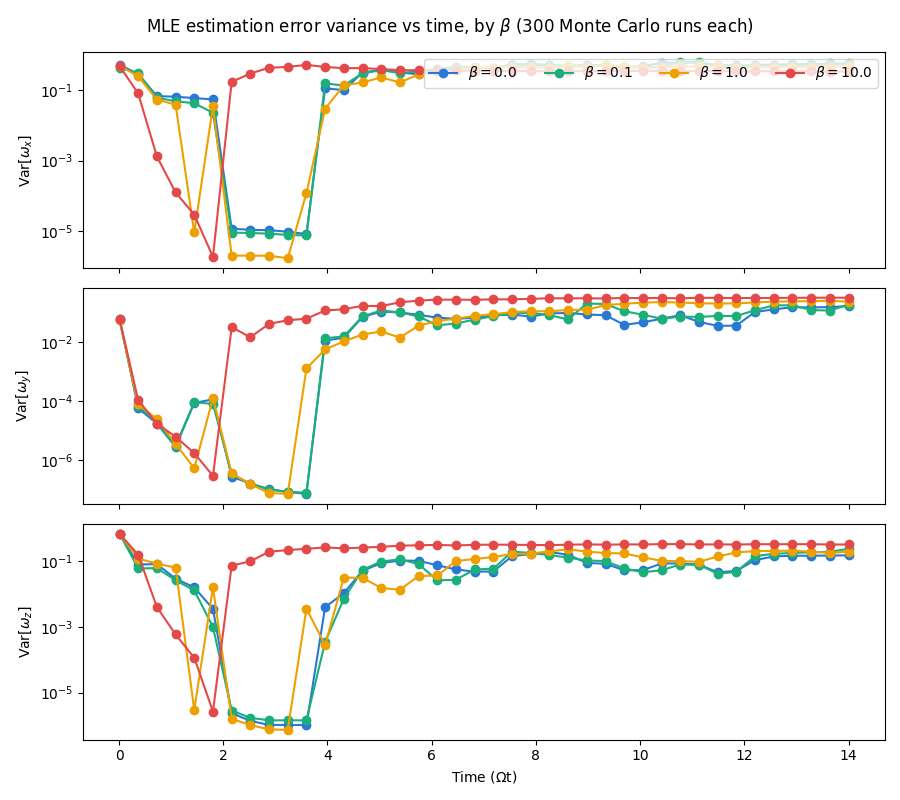

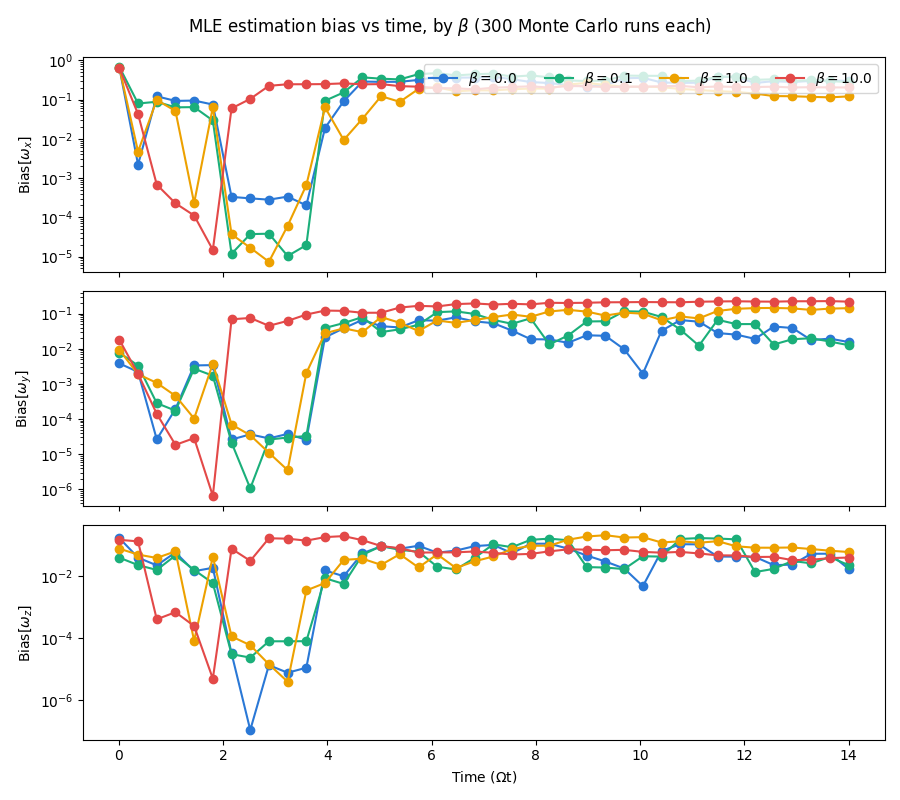

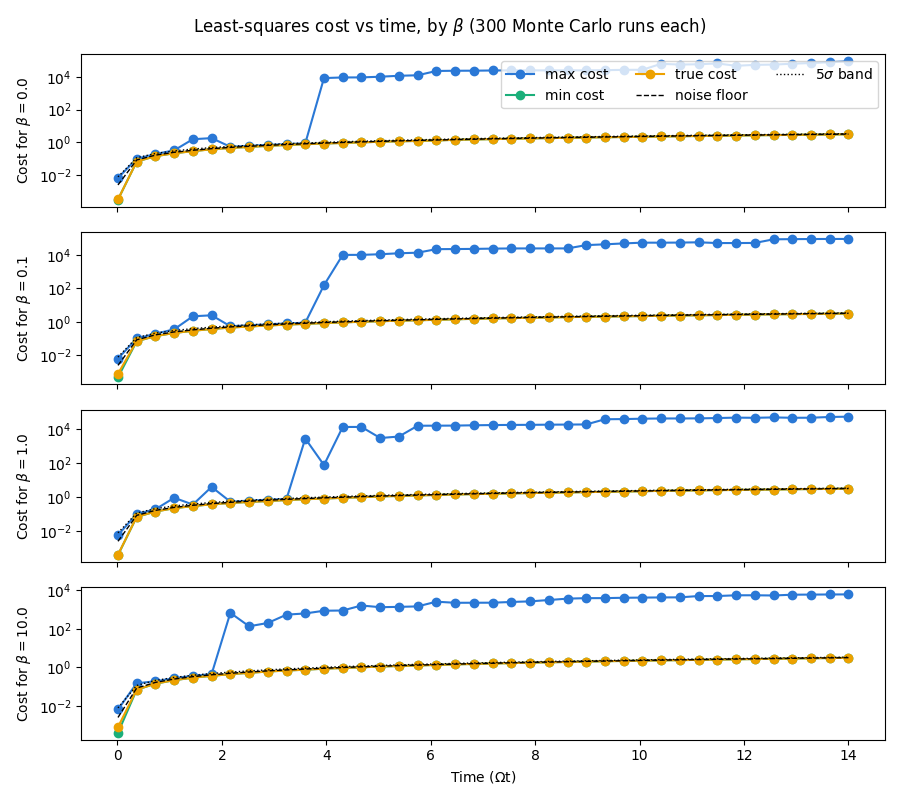

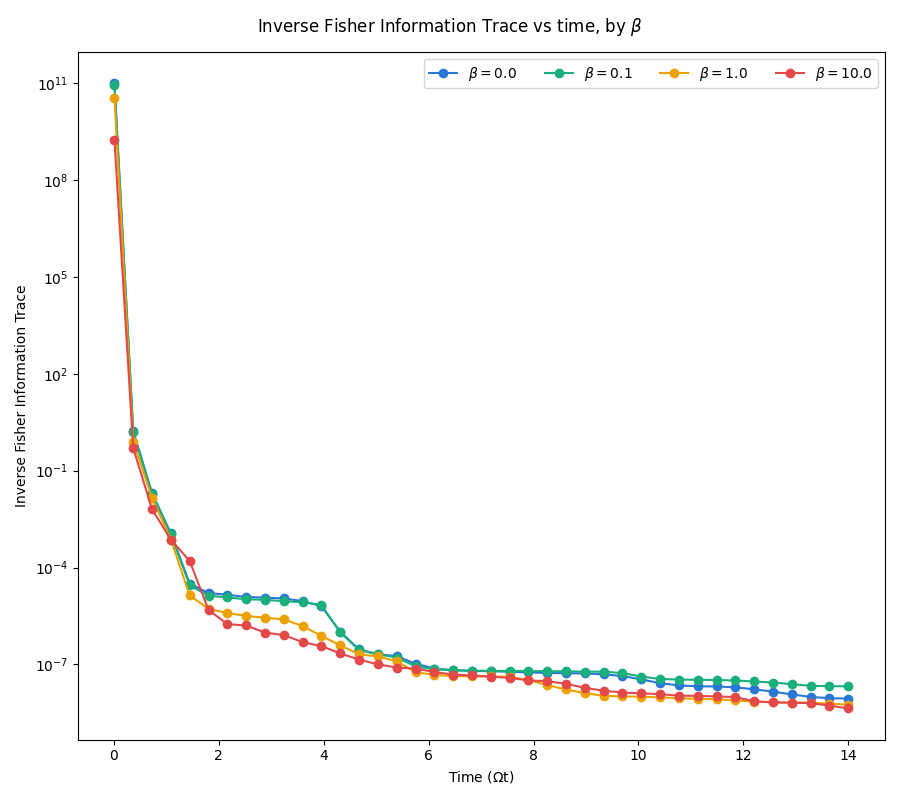

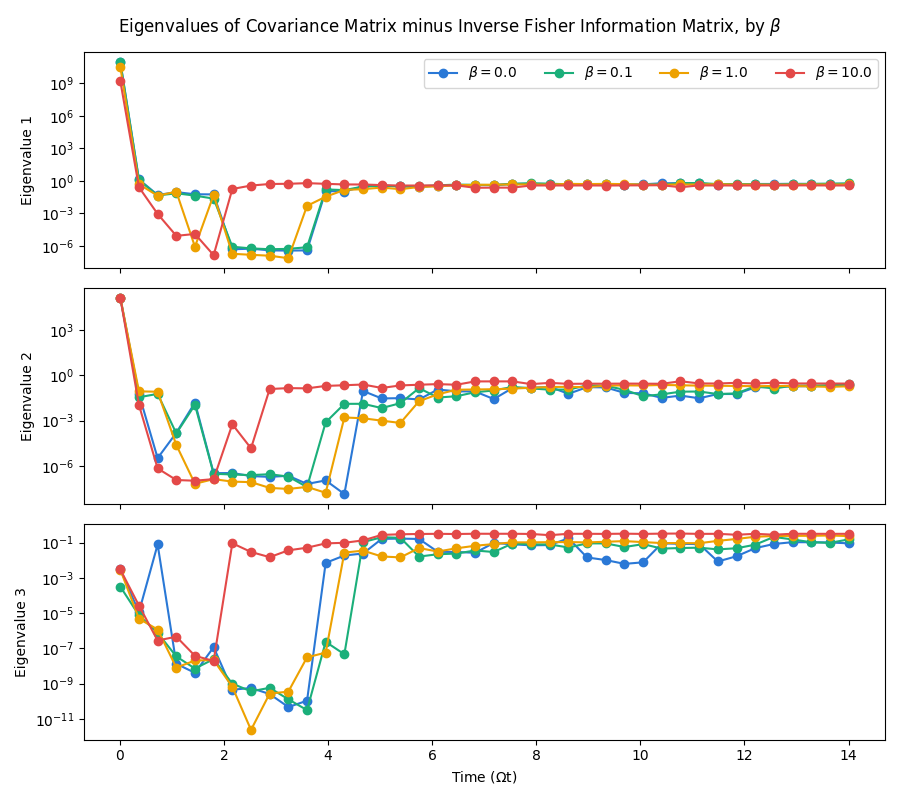

In [52]:
mle_over_time_8 = load_npy(r"C:\Users\alexg\python_scripts\corrected_FI_code\trotter_least_squares_over_time\data_mle_over_time_8")
mle_over_time = mle_over_time_8
labels_omega = [r'$\omega_x$', r'$\omega_y$', r'$\omega_z$']
beta_values = mle_over_time['beta_array']
checkpoint_times = mle_over_time['time_cutoffs_array']
beta_colors = ['#2a78d6', '#1baf7a', '#eda100','#e34948', '#008300', '#4a3aa7',  '#e87ba4', '#eb6834']
dt = 1e-3
omega_true = mle_over_time['w_true']

#Shot-noise cost floor: the residuals at w_true equal the injected noise, so
#E[cost at truth] = 0.5*n_sub*sn_sd^2. Fits whose cost leaves the 5-sigma
#chi-square band converged to a local minimum, not to the global one.
t_steps_run = 14000
n_sub = np.array([np.sum(np.linspace(0, t_steps_run, t_steps_run, dtype=int) <= tc) for tc in checkpoint_times])
sn_sd = 1/(np.sqrt(9.6e8/t_steps_run)*8.9e-7*2e5)
cost_floor = 0.5 * sn_sd**2 * n_sub
cost_band = 0.5 * sn_sd**2 * (n_sub + 5*np.sqrt(2*n_sub))

#Plot variance of MLE estimation error over time for different beta values
fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)
for j, lab in enumerate(labels_omega):
    for b_idx, beta in enumerate(beta_values):
        color = beta_colors[b_idx % len(beta_colors)]
        axes[j].semilogy(checkpoint_times*dt, mle_over_time['std_array'][b_idx][:,j], 'o-',
                            color=color, label=fr'$\beta={beta}$')
    axes[j].set_ylabel(f'Var[{lab}]')
axes[0].legend(loc='upper right', ncol=len(beta_values))
axes[-1].set_xlabel(f'Time ($\Omega$t)')
fig.suptitle(f'MLE estimation error variance vs time, by $\\beta$ (300 Monte Carlo runs each)')
plt.tight_layout()
#plt.savefig(r'C:\Users\alexg\OneDrive\Docs\UNM\Ivan Research\VSCode\Jupyter\plots\data_mle_over_time_1\mle_variance.png', dpi=300, bbox_inches='tight')
plt.show()

#Plot bias of MLE estimation error over time for different beta values
fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)
for j, lab in enumerate(labels_omega):
    for b_idx, beta in enumerate(beta_values):
        color = beta_colors[b_idx % len(beta_colors)]
        axes[j].semilogy(checkpoint_times*dt, np.abs(mle_over_time['bias'][b_idx][:,j]), 'o-',
                            color=color, label=fr'$\beta={beta}$')
    axes[j].set_ylabel(f'Bias[{lab}]')
axes[0].legend(loc='upper right', ncol=len(beta_values))
axes[-1].set_xlabel(f'Time ($\Omega$t)')
fig.suptitle(f'MLE estimation bias vs time, by $\\beta$ (300 Monte Carlo runs each)')
plt.tight_layout()
#plt.savefig(r'C:\Users\alexg\OneDrive\Docs\UNM\Ivan Research\VSCode\Jupyter\plots\data_mle_over_time_1\mle_bias.png', dpi=300, bbox_inches='tight')

plt.show()

#Plot least-squares cost of the kept fits over time for different beta values
#(cost_true is saved as 0.5*||residuals||^2 already; no extra 0.5 factor here)
fig, axes = plt.subplots(len(beta_values), 1, figsize=(9, 8), sharex=True)
for b_idx, beta in enumerate(beta_values):
    color = beta_colors[b_idx % len(beta_colors)]
    axes[b_idx].semilogy(checkpoint_times*dt, mle_over_time['max_cost_estimate'][b_idx][:], 'o-',
                            color=beta_colors[0], label=fr'max cost')
    axes[b_idx].semilogy(checkpoint_times*dt, mle_over_time['min_cost_estimate'][b_idx][:], 'o-',
                            color=beta_colors[1], label=fr'min cost')
    axes[b_idx].semilogy(checkpoint_times*dt, mle_over_time['cost_true'][b_idx][:], 'o-',
                            color=beta_colors[2], label=fr'true cost')
    axes[b_idx].semilogy(checkpoint_times*dt, cost_floor, 'k--', lw=1, label='noise floor')
    axes[b_idx].semilogy(checkpoint_times*dt, cost_band, 'k:', lw=1, label=r'$5\sigma$ band')
    axes[b_idx].set_ylabel(f'Cost for $\\beta = {beta}$')
axes[0].legend(loc='upper right', ncol=3)
axes[-1].set_xlabel(f'Time ($\Omega$t)')
fig.suptitle(f'Least-squares cost vs time, by $\\beta$ (300 Monte Carlo runs each)')
plt.tight_layout()
#plt.savefig(r'C:\Users\alexg\OneDrive\Docs\UNM\Ivan Research\VSCode\Jupyter\plots\data_mle_over_time_1\mle_bias.png', dpi=300, bbox_inches='tight')

plt.show()

#Plot Trace of inverse Fisher Information over time for different beta values
fig, axes = plt.subplots(1, 1, figsize=(9, 8), sharex=True)
for b_idx, beta in enumerate(beta_values):
    color = beta_colors[b_idx % len(beta_colors)]
    axes.semilogy(checkpoint_times*dt, mle_over_time['fisher_inv_trace'][b_idx][:], 'o-',
                            color=color, label=fr'$\beta={beta}$')
    axes.set_ylabel(f'Inverse Fisher Information Trace')
axes.legend(loc='upper right', ncol=len(beta_values))
axes.set_xlabel(f'Time ($\Omega$t)')
fig.suptitle(f'Inverse Fisher Information Trace vs time, by $\\beta$')
plt.tight_layout()
#plt.savefig(r'C:\Users\alexg\OneDrive\Docs\UNM\Ivan Research\VSCode\Jupyter\plots\data_mle_over_time_1\mle_bias.png', dpi=300, bbox_inches='tight')

plt.show()


#Plot Trace of inverse Fisher Information over time for different beta values
fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)
for j in range(3):
    for b_idx, beta in enumerate(beta_values):
        color = beta_colors[b_idx % len(beta_colors)]
        axes[j].semilogy(checkpoint_times*dt, np.abs(mle_over_time['CRB_diff_eig'][b_idx][:,j]), 'o-',
                                color=color, label=fr'$\beta={beta}$')
        axes[j].set_ylabel(f'Eigenvalue {j+1}')
axes[0].legend(loc='upper right', ncol=len(beta_values))
axes[-1].set_xlabel(f'Time ($\Omega$t)')
fig.suptitle(f'Eigenvalues of Covariance Matrix minus Inverse Fisher Information Matrix, by $\\beta$')
plt.tight_layout()
#plt.savefig(r'C:\Users\alexg\OneDrive\Docs\UNM\Ivan Research\VSCode\Jupyter\plots\data_mle_over_time_1\mle_bias.png', dpi=300, bbox_inches='tight')

plt.show()


MLE over time 9 (rng = 3; use 'lm' method instead and only 300 iter)